In [1]:
from pathlib import Path
import pandas as pd
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"

documents = {}

for file in DATA_DIR.glob("*.txt"):
    documents[file.stem] = file.read_text(encoding="utf-8")

print(f"Loaded {len(documents)} documents.")

Loaded 101 documents.


In [3]:
def clean_text(text):
    text = text.lower()
    
    # Remove page number markers like "p. 31"
    text = re.sub(r'\bp\.\s*\d+\b', ' ', text)
    
    # Remove standalone punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Fix common OCR join artefacts (optional)
    text = text.replace("ofthe", "of the")
    
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

cleaned_docs = {k: clean_text(v) for k, v in documents.items()}

# Corpus Document Analysis and Categories

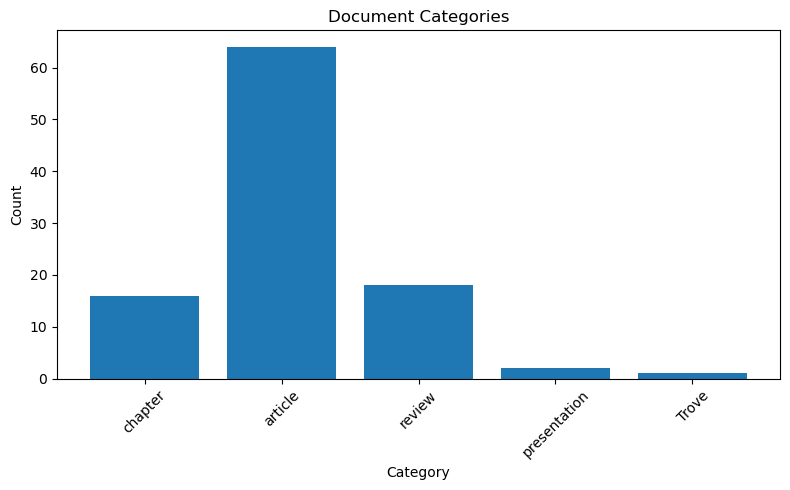

chapter: 16 documents
article: 64 documents
review: 18 documents
presentation: 2 documents
 Trove: 1 documents
Total: 101 documents


In [4]:
# Plot categories of documents using last section of filename categories as either "journal-article", "book-chapter", or "book-review"
categories = [name.split("-")[-1] for name in cleaned_docs.keys()]
category_counts = Counter(categories)
plt.figure(figsize=(8, 5))
plt.bar(category_counts.keys(), category_counts.values())
plt.title("Document Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#print number of items in each category with a 'total' number of documents at the end
total_documents = sum(category_counts.values())
for category, count in category_counts.items():
    print(f"{category}: {count} documents")
print(f"Total: {total_documents} documents") 

# Corpus Level Word Frequency

In [5]:
all_words = " ".join(cleaned_docs.values()).split()
freq = Counter(all_words)

freq.most_common(20)

[('the', 39759),
 ('of', 27036),
 ('and', 19921),
 ('in', 13775),
 ('to', 13005),
 ('a', 12031),
 ('is', 7584),
 ('that', 6628),
 ('s', 6420),
 ('as', 6080),
 ('for', 3875),
 ('by', 3725),
 ('it', 3641),
 ('with', 3598),
 ('this', 3227),
 ('wright', 3201),
 ('on', 3154),
 ('indigenous', 2937),
 ('from', 2856),
 ('an', 2809)]

In [6]:
"""
Identify most common content words in the corpus
(after removing stopwords and domain-specific noise)
"""

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter

# ----------------------------
# 1. Remove standard stopwords
# ----------------------------
filtered_words = [
    w for w in all_words
    if w not in ENGLISH_STOP_WORDS
]

# ----------------------------
# 2. Define domain-specific exclusions
# ----------------------------
remove_terms = {
    'carpentaria', 'wright', 'alexis', 's'
}

noise_terms = {
    'functionality', 'licensors', 'warranties', 'cengage',
    'gale', 'machine', 'generated', 'pdf',
    'copyright', 'reproduced', 'permission',
    'vol', 'issue', 'page', 'pp', 'p',
    'feb', 'february',
    'informit', 'timrofni', 'ylrehtuos',
    'eht', 'fo', 'like'
}

# NOTE: you removed 'indigenous' and 'aboriginal' earlier
# consider whether you actually want to exclude these,
# as they may be analytically important

exclusion_terms = remove_terms.union(noise_terms)

# ----------------------------
# 3. Final filtering
# ----------------------------
filtered_words = [
    w for w in filtered_words
    if len(w) > 2 and w not in exclusion_terms
]

# ----------------------------
# 4. Count frequencies
# ----------------------------
word_counts = Counter(filtered_words)

top_words = word_counts.most_common(20)

# Display
for word, count in top_words:
    print(f"{word}: {count}")

indigenous: 2937
aboriginal: 2380
australian: 2019
novel: 1775
people: 1569
australia: 1247
literature: 1210
world: 1115
land: 1079
white: 1053
new: 1015
time: 1006
story: 969
country: 952
literary: 910
narrative: 889
history: 883
writing: 858
place: 761
cultural: 723


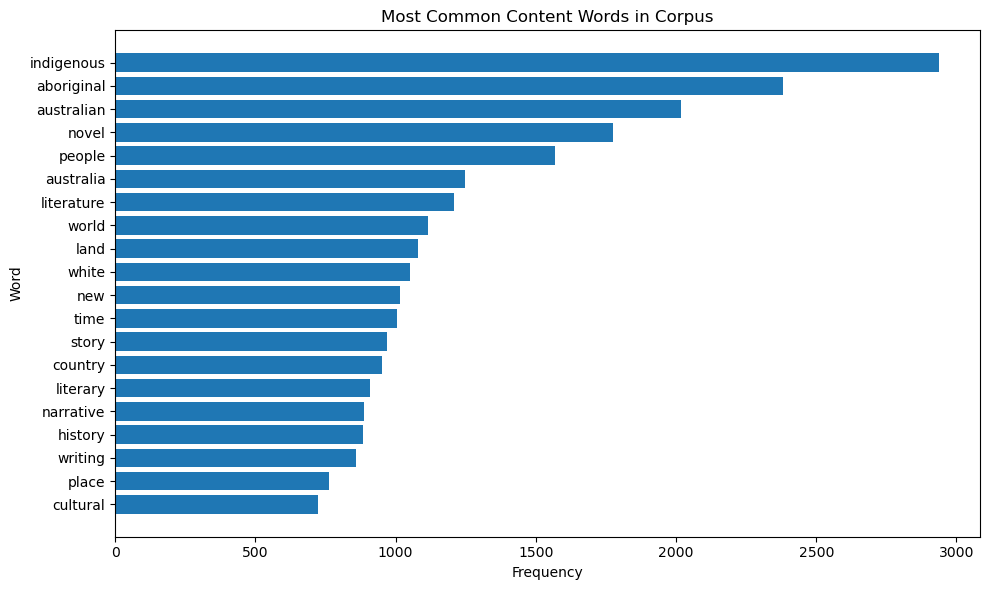

In [7]:
import matplotlib.pyplot as plt

if top_words:
    words = [word for word, count in top_words]
    counts = [count for word, count in top_words]

    plt.figure(figsize=(10, 6))
    plt.barh(words[::-1], counts[::-1])

    plt.title("Most Common Content Words in Corpus")
    plt.xlabel("Frequency")
    plt.ylabel("Word")

    plt.tight_layout()
    plt.show()
else:
    print("No words available to plot.")

Ths indicates that The corpus is centrally concerned with Indigenous identity, and secondly strongly situates Indigenous discourse within a national and spatial context (australia, land, country, place), particularly Australia, land, and settler relations. The The presence of “white” could suggests colonial or racial framing and likely indicates critical or comparative discourse. There is also a literary and analytical vocabulary (novel, literature, literary, narrative, story, writing) The corpus is clearly literary-critical in nature, focusing on textual analysis rather than purely historical or political discourse. There is also an evident thematic vocabulary that engages conceptual frameworks such as history, culture, and temporality (history, cultural, world, time). 

Using terms: ['indigenous', 'aboriginal', 'land', 'country', 'history', 'time', 'white', 'whiteness']


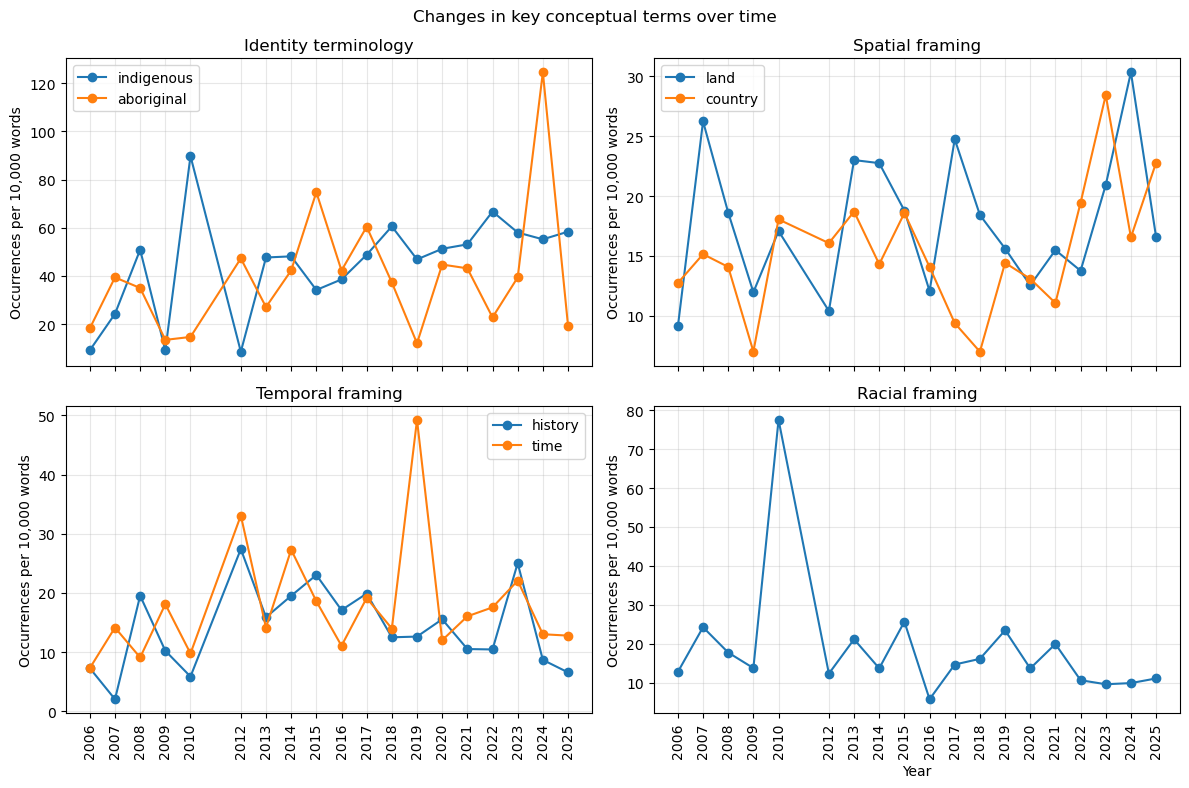

In [8]:
"""
Unigram temporal analysis
(normalised per 10,000 words)
"""

import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# ----------------------------
# 1. Prepare dataframe
# ----------------------------
def extract_year(filename):
    match = re.search(r"(19|20)\d{2}", filename)
    return int(match.group()) if match else None

doc_names = list(cleaned_docs.keys())
texts = list(cleaned_docs.values())

df = pd.DataFrame({
    "filename": doc_names,
    "text": texts
})

df["year"] = df["filename"].apply(extract_year)
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

# ----------------------------
# 2. Word counts
# ----------------------------
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

# ----------------------------
# 3. Unigram matrix
# ----------------------------
vectorizer = CountVectorizer(ngram_range=(1,1), stop_words="english")
X = vectorizer.fit_transform(df["text"])

unigram_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

unigram_df["year"] = df["year"].values
unigram_df["word_count"] = df["word_count"].values

# ----------------------------
# 4. Select terms
# ----------------------------
target_terms = [
    "indigenous",
    "aboriginal",
    "land",
    "country",
    "history",
    "time",
    "white",
    "whiteness"

    
]

available_terms = [t for t in target_terms if t in unigram_df.columns]

print("Using terms:", available_terms)

# ----------------------------
# 5. Aggregate by year
# ----------------------------
yearly = (
    unigram_df.groupby("year")[available_terms + ["word_count"]]
    .sum()
    .rename(columns={"word_count": "total_words"})
    .sort_index()
)

# ----------------------------
# 6. Normalise per 10,000 words
# ----------------------------
for term in available_terms:
    yearly[f"{term}_per_10k"] = (
        yearly[term] / yearly["total_words"]
    ) * 10000

# ----------------------------
# 7. Plot grouped comparisons (with analytical titles)
# ----------------------------
plot_groups = [
    (["indigenous", "aboriginal"], "Identity terminology"),
    (["land", "country"], "Spatial framing"),
    (["history", "time"], "Temporal framing"),
    (["white"], "Racial framing")
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

years = yearly.index.astype(int)

for ax, (group, title) in zip(axes, plot_groups):
    for term in group:
        if term in available_terms:
            ax.plot(
                years,
                yearly[f"{term}_per_10k"],
                marker="o",
                label=term
            )

    ax.set_title(title)
    ax.set_ylabel("Occurrences per 10,000 words")
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(True, alpha=0.3)

    # Only show legend if multiple terms
    if len(group) > 1:
        ax.legend()

plt.xlabel("Year")
plt.suptitle("Changes in key conceptual terms over time")
plt.tight_layout()
plt.show()

In [9]:
"""
TF-IDF analysis by year with expanded top-term tracking
"""

import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# ----------------------------
# 1. Prepare dataframe
# ----------------------------
def extract_year(filename):
    match = re.search(r"(19|20)\d{2}", filename)
    return int(match.group()) if match else None

doc_names = list(cleaned_docs.keys())
texts = list(cleaned_docs.values())

df = pd.DataFrame({
    "filename": doc_names,
    "text": texts
})

df["year"] = df["filename"].apply(extract_year)
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)

# ----------------------------
# 2. Combine texts by year
# ----------------------------
yearly_texts = (
    df.groupby("year")["text"]
    .apply(lambda texts: " ".join(texts))
    .sort_index()
)

# ----------------------------
# 3. Compute TF-IDF
# ----------------------------
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    stop_words="english",
    min_df=2
)

X_tfidf = tfidf_vectorizer.fit_transform(yearly_texts.values)
terms = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    index=yearly_texts.index,
    columns=terms
)

# ----------------------------
# 4. Extract top terms per year
# ----------------------------
top_n = 30
rows = []

for year in tfidf_df.index:
    top_terms = (
        tfidf_df.loc[year]
        .sort_values(ascending=False)
        .head(top_n)
    )
    
    for rank, (term, score) in enumerate(top_terms.items(), start=1):
        rows.append({
            "year": year,
            "rank": rank,
            "term": term,
            "tfidf_score": score
        })

top_terms_df = pd.DataFrame(rows)

print("=== Top TF-IDF terms by year ===")
display(top_terms_df)

# ----------------------------
# 5. Count how often terms recur across years
# ----------------------------
term_recurrence = (
    top_terms_df.groupby("term")
    .agg(
        years_present=("year", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
        avg_tfidf=("tfidf_score", "mean")
    )
    .sort_values(
        by=["years_present", "avg_tfidf"],
        ascending=[False, False]
    )
    .reset_index()
)

print("=== Terms recurring across years ===")
display(term_recurrence.head(50))

=== Top TF-IDF terms by year ===


,year,rank,term,tfidf_score
0,2006,1,abr,0.415759
1,2006,2,reviews,0.318387
2,2006,3,wright,0.291964
3,2006,4,carpentaria,0.257324
4,2006,5,online,0.191168
...,...,...,...,...
565,2025,26,land,0.074982
566,2025,27,political,0.073420
567,2025,28,pp,0.070696
568,2025,29,rubbish,0.068974


=== Terms recurring across years ===


,term,years_present,first_year,last_year,avg_tfidf
0,wright,19,2006,2025,0.238021
1,carpentaria,19,2006,2025,0.197266
2,novel,19,2006,2025,0.133300
3,australian,17,2007,2025,0.152376
4,indigenous,16,2007,2025,0.238753
5,aboriginal,15,2007,2025,0.211116
6,people,15,2007,2024,0.147454
7,australia,13,2006,2024,0.106753
8,land,12,2007,2025,0.097765
9,world,11,2008,2023,0.104527


In [10]:
term_year_presence = (
    top_terms_df.assign(present=1)
    .pivot_table(
        index="term",
        columns="year",
        values="present",
        fill_value=0
    )
)

display(term_year_presence.head(30))

year,2006,2007,2008,2009,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
term,,,,,,,,,,,,,,,,,,,
aboriginal,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
aborigines,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
abr,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
alexis,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
allauthors,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
als,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
american,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
anthropocene,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
apocalypse,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
"""
TF-IDF analysis by year (with exclusion of noise and text-specific terms)
"""

import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# ----------------------------
# 1. Prepare dataframe
# ----------------------------
def extract_year(filename):
    match = re.search(r"(19|20)\d{2}", filename)
    return int(match.group()) if match else None

doc_names = list(cleaned_docs.keys())
texts = list(cleaned_docs.values())

df = pd.DataFrame({
    "filename": doc_names,
    "text": texts
})

df["year"] = df["filename"].apply(extract_year)
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)

# ----------------------------
# 2. Combine all documents within each year
# ----------------------------
yearly_texts = (
    df.groupby("year")["text"]
    .apply(lambda texts: " ".join(texts))
    .sort_index()
)

# ----------------------------
# 3. Define exclusion terms
# ----------------------------
exclusion_terms = [
    # authors / texts
    "wright", "carpentaria", "alexis",
    
    # OCR / artefacts
    "yduts", "nailartsua", "erutaretil", "noitaicossa", "lanruoj"  "nailartsua", "eht", "fo", "morf", "enruoblem", "ytisrevinu", "abr", "abr", "reviews", "online", "australianbookreview", 
    "eu", "page", "archive", "october",  "component", "https", "net", "author", 
    "issue", "ns", "cy", "com", "print", "oceania", "current", "www", "au", "pg", "allauthors", "tag", "byalexiswright",
    
    # generic / low-value
    "people", "new", "like", "book", "review"
]

# ----------------------------
# 4. Compute TF-IDF
# ----------------------------
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    stop_words="english",
    min_df=2
)

X_tfidf = tfidf_vectorizer.fit_transform(yearly_texts.values)
terms = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    index=yearly_texts.index,
    columns=terms
)

# ----------------------------
# 5. Remove unwanted terms
# ----------------------------
tfidf_df = tfidf_df.drop(
    columns=[t for t in exclusion_terms if t in tfidf_df.columns],
    errors="ignore"
)

# ----------------------------
# 6. Extract top terms per year
# ----------------------------
top_n = 30  # expanded for better tracking

top_terms_by_year = {}

for year in tfidf_df.index:
    top_terms = (
        tfidf_df.loc[year]
        .sort_values(ascending=False)
        .head(top_n)
    )
    top_terms_by_year[year] = pd.DataFrame({
        "term": top_terms.index,
        "tfidf_score": top_terms.values
    })

# ----------------------------
# 7. Display results
# ----------------------------
for year, table in top_terms_by_year.items():
    print(f"\n=== {year} ===")
    display(table)


=== 2006 ===


,term,tfidf_score
0,kate,0.120844
1,novel,0.113817
2,australia,0.094022
3,shesays,0.086019
4,town,0.079177
5,yorta,0.077478
6,english,0.067631
7,phantom,0.054434
8,norm,0.054434
9,desperance,0.054434



=== 2007 ===


,term,tfidf_score
0,aboriginal,0.177297
1,norm,0.172751
2,sea,0.159113
3,town,0.136382
4,novel,0.136382
5,man,0.131836
6,land,0.118198
7,desperance,0.113652
8,indigenous,0.109106
9,white,0.109106



=== 2008 ===


...

,term,tfidf_score
0,indigenous,0.276861
1,aboriginal,0.187831
2,nature,0.162859
3,western,0.143316
4,country,0.135716
5,scott,0.127382
6,australian,0.127030
7,colonial,0.126013
8,ecological,0.124956
9,world,0.121602



=== 2024 ===


,term,tfidf_score
0,aboriginal,0.520949
1,indigenous,0.230800
2,australian,0.179694
3,literary,0.133534
4,roam,0.128955
5,land,0.126940
6,orality,0.120775
7,cultural,0.115400
8,als,0.098942
9,cf,0.098942



=== 2025 ===


,term,tfidf_score
0,indigenous,0.263998
1,infrastructure,0.249761
2,listening,0.215909
3,infrastructures,0.175201
4,gothic,0.147265
5,settler,0.144518
6,reading,0.136306
7,novel,0.134342
8,pedagogy,0.126741
9,island,0.106224


TF-IDF highlights which terms are especially characteristic of particular years.

Early period: narrative and spatial grounding (2007–2009)
The earliest years of the corpus are characterised by a combination of narrative, spatial, and community-oriented vocabulary. In 2007, terms such as land, aboriginal, story, and white appear alongside more localised and narrative-specific terms, suggesting a focus on situated storytelling and lived experience. This emphasis continues into 2008, where indigenous, aboriginal, history, land, and country emerge as distinctive terms, indicating a consolidation of identity and spatial discourse within a national framework. By 2009, however, the vocabulary shifts towards a more explicitly literary and transnational orientation, with terms such as literature, writing, asian, and chinese becoming prominent. Taken together, this early period reflects a transition from grounded, narrative-driven representations of Indigenous experience to a more formalised literary and comparative framework.
Intersection of identity, race, and literary form (2010)
The year 2010 represents a particularly concentrated moment in which identity, race, and literary form intersect. The high TF-IDF scores for indigenous and white, alongside the emergence of magic, magical, and realism, indicate a simultaneous engagement with racial discourse and literary mode. The presence of sovereignty further suggests that questions of political authority and Indigenous self-determination are becoming more central. This combination of terms points to a period in which literary analysis is closely tied to both aesthetic frameworks and critical examinations of race and power.
Theoretical spatial expansion (2012–2013)
In 2012, the corpus shifts towards a more abstract and theoretically informed spatial vocabulary. Terms such as island, space, and heterotopia dominate the TF-IDF profile, indicating a strong engagement with spatial theory and conceptual frameworks of place. This suggests a move beyond concrete representations of land towards more complex, theoretical understandings of spatiality. By 2013, this spatial emphasis is integrated with broader literary and cultural analysis, as seen in the prominence of land, country, cultural, and literature, alongside white and mining. This indicates an expansion of spatial discourse to include both cultural and material dimensions, including the beginnings of attention to resource extraction.
Consolidation of literary and political discourse (2014–2017)
Between 2014 and 2017, the corpus demonstrates a consolidation of literary-critical and political vocabulary. In 2014, terms such as indigenous, aboriginal, story, narrative, and mining appear together, suggesting an integration of narrative analysis with material concerns. By 2016 and 2017, this develops further into a more explicitly political register, with sovereignty, reconciliation, colonial, and land becoming prominent. These years reflect a period in which literary analysis is increasingly aligned with political discourse, particularly in relation to Indigenous rights and colonial histories.
Global and environmental turn (2018–2019)
A significant thematic shift occurs in 2018 and 2019, where the corpus expands into global and environmental frameworks. In 2018, terms such as cosmopolitanism, transnational, and global indicate a widening of perspective beyond the national context. This culminates in 2019 with the emergence of anthropocene, climate, change, and environmental, marking a clear turn towards ecological discourse. The prominence of temporal terms such as temporality and future further suggests that environmental concerns are being framed within broader temporal and planetary contexts.
Reconfiguration of literary and political concerns (2020–2022)
From 2020 onwards, the corpus exhibits a reconfiguration of earlier themes. In 2020, mining, magical, and realism reappear alongside indigenous and literature, indicating a renewed engagement with both material and aesthetic concerns. By 2021 and 2022, this develops into a more diversified discourse, with terms such as settler, justice, knowledge, and narrative appearing alongside continued references to land and country. This suggests a broadening of analytical focus, incorporating ethical, epistemological, and interdisciplinary perspectives.
Intensification of identity and political discourse (2023–2025)
The most recent years of the corpus are marked by a renewed intensification of identity and political discourse. In 2023, terms such as indigenous, aboriginal, country, colonial, and ecological appear together, indicating a convergence of identity, spatial, and environmental concerns. This intensifies further in 2024, where aboriginal reaches a particularly high TF-IDF score, accompanied by sovereignty, settler, and colonial, signalling a strong emphasis on political and decolonial frameworks. By 2025, the vocabulary shifts again towards terms such as infrastructure, settler, ethics, and political, suggesting an increasing engagement with institutional and systemic dimensions of Indigenous discourse.
Overall interpretation
Taken together, these yearly TF-IDF profiles demonstrate that while the corpus is structured around a stable set of core concepts, including Indigenous identity and land, it undergoes significant shifts in emphasis over time. Early years are characterised by narrative and spatial grounding, followed by periods of theoretical expansion, political consolidation, and global environmental engagement. More recent years reflect an intensification of decolonial and institutional concerns. This pattern indicates that the corpus is both thematically coherent and dynamically responsive to changing intellectual and political contexts.

Using focus terms: ['sovereignty', 'settler', 'colonial', 'law', 'mining', 'climate_change', 'island', 'space', 'magical_realism', 'listening']


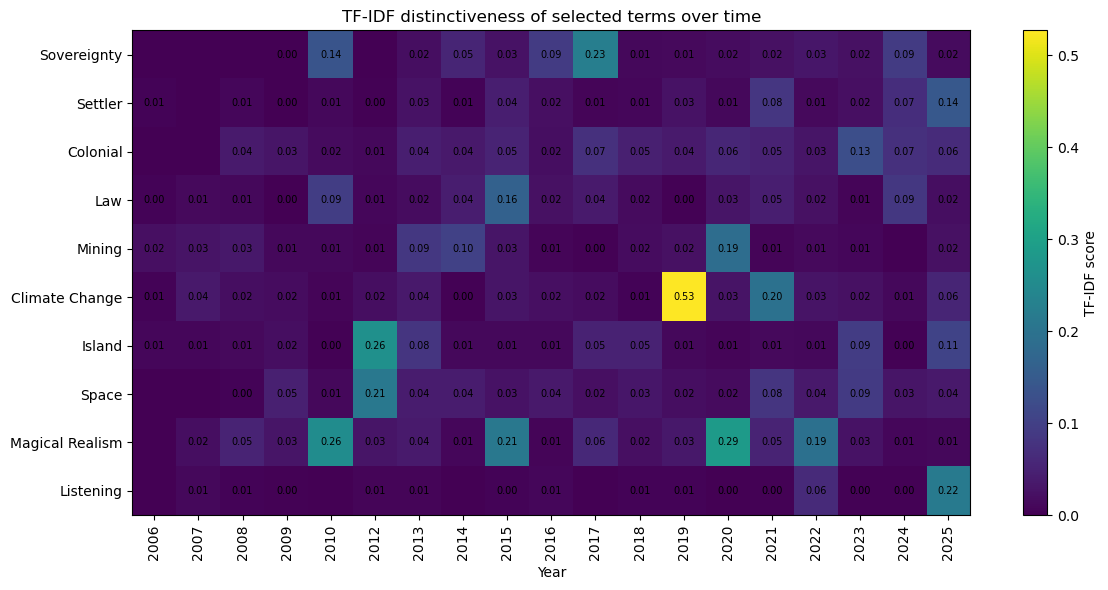

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# 1. Create combined terms
# ----------------------------
# Magical realism
tfidf_df["magical_realism"] = 0
if "magical" in tfidf_df.columns:
    tfidf_df["magical_realism"] += tfidf_df["magical"]
if "realism" in tfidf_df.columns:
    tfidf_df["magical_realism"] += tfidf_df["realism"]

# Climate change
tfidf_df["climate_change"] = 0
if "climate" in tfidf_df.columns:
    tfidf_df["climate_change"] += tfidf_df["climate"]
if "change" in tfidf_df.columns:
    tfidf_df["climate_change"] += tfidf_df["change"]

# ----------------------------
# 2. Define selected terms
# ----------------------------
selected_focus_terms = [
    "sovereignty",
    "settler",
    "colonial",
    "law",
    "mining",
    "climate_change",
    "island",
    "space",
    "magical_realism",
    "listening"
]

# ----------------------------
# 3. Filter available terms
# ----------------------------
available_focus_terms = [t for t in selected_focus_terms if t in tfidf_df.columns]
print("Using focus terms:", available_focus_terms)

focus_tfidf = tfidf_df[available_focus_terms].copy()
years = focus_tfidf.index.astype(int)

# ----------------------------
# 4. Prepare heatmap data
# ----------------------------
heatmap_data = focus_tfidf.T.values  # terms as rows, years as columns

# Make labels more readable
display_labels = [
    term.replace("_", " ").title()
    for term in available_focus_terms
]

# ----------------------------
# 5. Plot heatmap
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    interpolation="nearest"
)

# Axis labels
ax.set_xticks(np.arange(len(years)))
ax.set_xticklabels(years, rotation=90)
ax.set_yticks(np.arange(len(display_labels)))
ax.set_yticklabels(display_labels)

ax.set_xlabel("Year")
ax.set_title("TF-IDF distinctiveness of selected terms over time")

# Add colour bar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("TF-IDF score")

# Optional: annotate cells with values
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data[i, j]
        if value > 0:
            ax.text(
                j, i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=7
            )

plt.tight_layout()
plt.show()

In [13]:
# ----------------------------
# Combine top terms into one dataframe
# ----------------------------
rows = []

for year, table in top_terms_by_year.items():
    for _, row in table.iterrows():
        rows.append({
            "year": year,
            "term": row["term"],
            "tfidf_score": row["tfidf_score"]
        })

top_terms_df = pd.DataFrame(rows)

display(top_terms_df.head())

,year,term,tfidf_score
0,2006,kate,0.120844
1,2006,novel,0.113817
2,2006,australia,0.094022
3,2006,shesays,0.086019
4,2006,town,0.079177


In [14]:
term_summary = (
    top_terms_df.groupby("term")
    .agg(
        years_present=("year", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
        avg_tfidf=("tfidf_score", "mean"),
        max_tfidf=("tfidf_score", "max")
    )
    .sort_values(
        by=["years_present", "avg_tfidf"],
        ascending=[False, False]
    )
    .reset_index()
)

display(term_summary.head(50))

,term,years_present,first_year,last_year,avg_tfidf,max_tfidf
0,novel,19,2006,2025,0.133300,0.219804
1,aboriginal,18,2006,2025,0.185190,0.520949
2,australian,17,2007,2025,0.152376,0.289492
3,indigenous,16,2007,2025,0.238753,0.379808
4,australia,16,2006,2024,0.098893,0.147749
5,land,14,2007,2025,0.092460,0.132503
6,world,12,2008,2023,0.101083,0.151499
7,time,12,2007,2023,0.094292,0.178857
8,country,12,2007,2025,0.081454,0.135716
9,literature,10,2009,2025,0.119842,0.181900


Using focus terms: ['sovereignty', 'settler', 'colonial', 'law', 'mining', 'climate_change', 'anthropocene', 'island', 'space', 'magical_realism', 'postcolonial', 'listening', 'reading', 'world', 'white_whiteness', 'country', 'land', 'place']


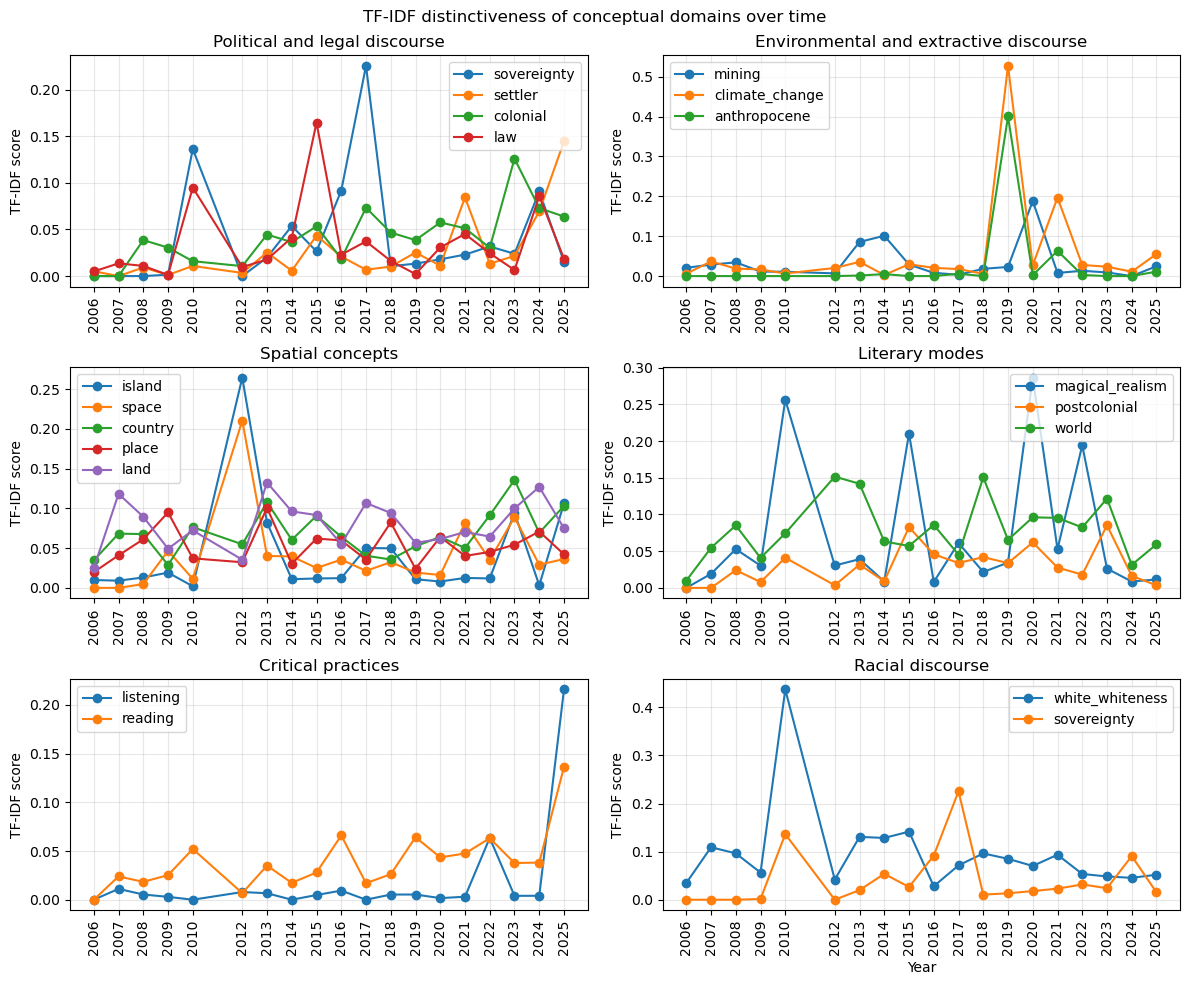

In [41]:
import matplotlib.pyplot as plt

# ----------------------------
# 1. Create combined terms
# ----------------------------
# Magical realism
tfidf_df["magical_realism"] = 0
if "magical" in tfidf_df.columns:
    tfidf_df["magical_realism"] += tfidf_df["magical"]
if "realism" in tfidf_df.columns:
    tfidf_df["magical_realism"] += tfidf_df["realism"]

# Climate change
tfidf_df["climate_change"] = 0
if "climate" in tfidf_df.columns:
    tfidf_df["climate_change"] += tfidf_df["climate"]
if "change" in tfidf_df.columns:
    tfidf_df["climate_change"] += tfidf_df["change"]

# White + whiteness
tfidf_df["white_whiteness"] = 0
if "white" in tfidf_df.columns:
    tfidf_df["white_whiteness"] += tfidf_df["white"]
if "whiteness" in tfidf_df.columns:
    tfidf_df["white_whiteness"] += tfidf_df["whiteness"]

# ----------------------------
# 2. Define selected terms
# ----------------------------
selected_focus_terms = [
    "sovereignty",
    "settler",
    "colonial",
    "law",
    "mining",
    "climate_change",
    "anthropocene",
    "island",
    "space",
    "magical_realism",
    "postcolonial",
    "listening",
    "reading",
    "world",
    "white_whiteness",
    "country",
    "land",
    "place"
]

# ----------------------------
# 3. Filter available terms
# ----------------------------
available_focus_terms = [t for t in selected_focus_terms if t in tfidf_df.columns]
print("Using focus terms:", available_focus_terms)

focus_tfidf = tfidf_df[available_focus_terms].copy()
years = focus_tfidf.index.astype(int)

# ----------------------------
# 4. Define conceptual groups
# ----------------------------
plot_groups = [
    (["sovereignty", "settler", "colonial", "law"], "Political and legal discourse"),
    (["mining", "climate_change", "anthropocene"], "Environmental and extractive discourse"),
    (["island", "space", "country", "place", "land"], "Spatial concepts"),
    (["magical_realism", "postcolonial", "world"], "Literary modes"),
    (["listening", "reading"], "Critical practices"),
    (["white_whiteness", "sovereignty"], "Racial discourse")
]

# ----------------------------
# 5. Plot
# ----------------------------
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10), sharex=False)
axes = axes.flatten()

for ax, (group, title) in zip(axes, plot_groups):
    plotted = []

    for term in group:
        if term in focus_tfidf.columns:
            ax.plot(
                years,
                focus_tfidf[term],
                marker="o",
                label=term
            )
            plotted.append(term)

    ax.set_title(title)
    ax.set_ylabel("TF-IDF score")
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=90)
    ax.grid(True, alpha=0.3)

    if len(plotted) > 1:
        ax.legend()

# Remove unused subplot (if any)
for j in range(len(plot_groups), len(axes)):
    fig.delaxes(axes[j])

plt.xlabel("Year")
plt.suptitle("TF-IDF distinctiveness of conceptual domains over time")
plt.tight_layout()
plt.show()

Using focus terms: ['sovereignty', 'settler', 'colonial', 'law', 'mining', 'climate_change', 'island', 'space', 'magical_realism', 'listening', 'anthropocene', 'reading', 'postcolonial']


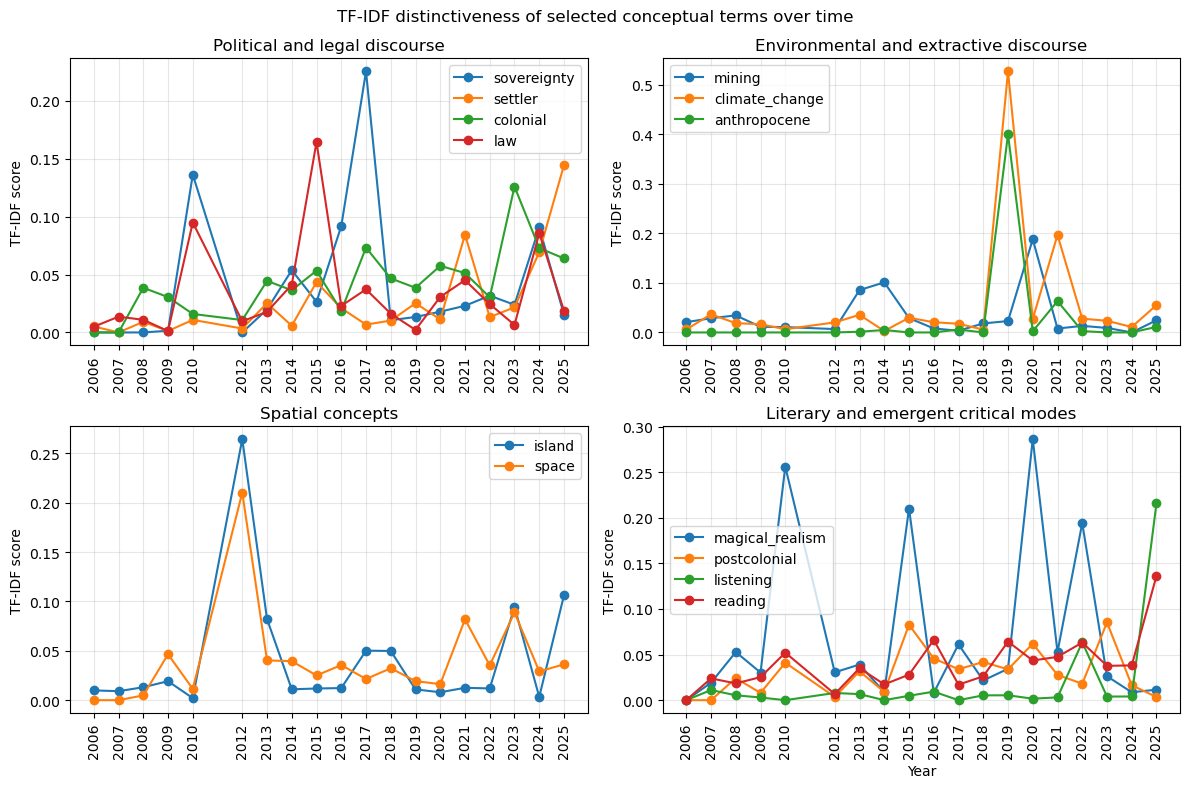

In [16]:
import matplotlib.pyplot as plt

# ----------------------------
# 1. Create combined terms
# ----------------------------
# Magical realism
tfidf_df["magical_realism"] = 0
if "magical" in tfidf_df.columns:
    tfidf_df["magical_realism"] += tfidf_df["magical"]
if "realism" in tfidf_df.columns:
    tfidf_df["magical_realism"] += tfidf_df["realism"]

# Climate change
tfidf_df["climate_change"] = 0
if "climate" in tfidf_df.columns:
    tfidf_df["climate_change"] += tfidf_df["climate"]
if "change" in tfidf_df.columns:
    tfidf_df["climate_change"] += tfidf_df["change"]

# ----------------------------
# 2. Define selected terms
# ----------------------------
selected_focus_terms = [
    "sovereignty",
    "settler",
    "colonial",
    "law",
    "mining",
    "climate_change",
    "island",
    "space",
    "magical_realism",
    "listening",
    "anthropocene",
    "reading",
    "postcolonial"
]

# ----------------------------
# 3. Filter available terms
# ----------------------------
available_focus_terms = [t for t in selected_focus_terms if t in tfidf_df.columns]
print("Using focus terms:", available_focus_terms)

focus_tfidf = tfidf_df[available_focus_terms].copy()
years = focus_tfidf.index.astype(int)

# ----------------------------
# 4. Define conceptual groups
# ----------------------------
plot_groups = [
    (["sovereignty", "settler", "colonial", "law"], "Political and legal discourse"),
    (["mining", "climate_change", "anthropocene"], "Environmental and extractive discourse"),
    (["island", "space"], "Spatial concepts"),
    (["magical_realism", "postcolonial", "listening", "reading"], "Literary and emergent critical modes")
]

# ----------------------------
# 5. Plot
# ----------------------------
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharex=False)
axes = axes.flatten()

for ax, (group, title) in zip(axes, plot_groups):
    plotted = []

    for term in group:
        if term in focus_tfidf.columns:
            ax.plot(
                years,
                focus_tfidf[term],
                marker="o",
                label=term
            )
            plotted.append(term)

    ax.set_title(title)
    ax.set_ylabel("TF-IDF score")
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=90)
    ax.grid(True, alpha=0.3)

    if len(plotted) > 1:
        ax.legend()

plt.xlabel("Year")
plt.suptitle("TF-IDF distinctiveness of selected conceptual terms over time")
plt.tight_layout()
plt.show()

Using TF-IDF terms: ['indigenous', 'time', 'aboriginal', 'land', 'country', 'place', 'space', 'island', 'history', 'literature', 'narrative', 'white', 'sovereignty', 'magical_realism', 'mining', 'climate']


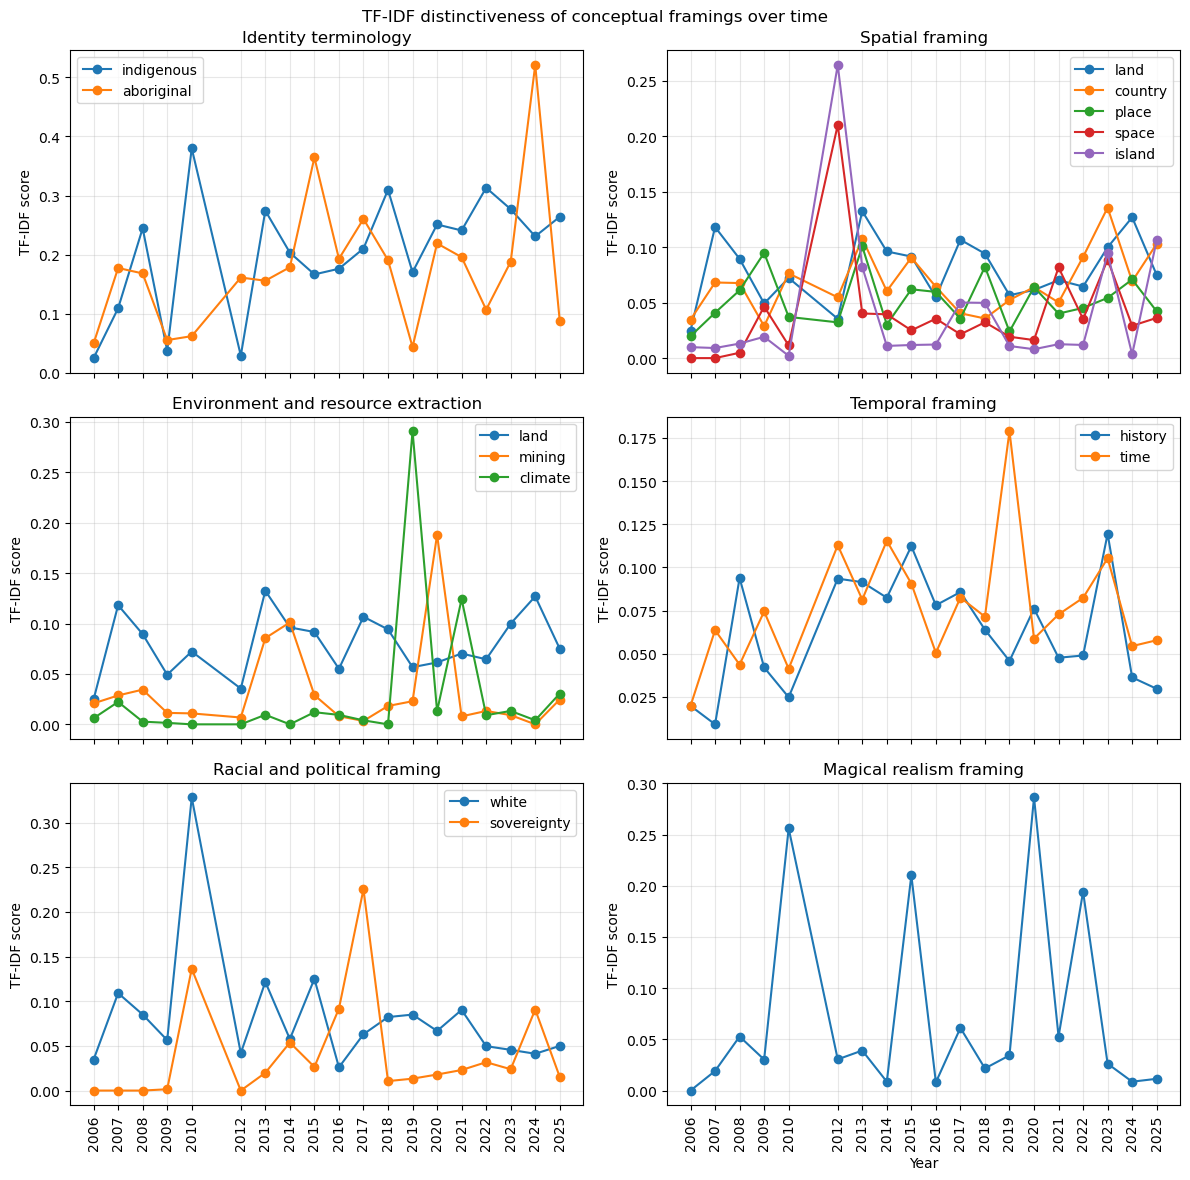

In [17]:
"""
TF-IDF plotting with expanded spatial terms
and combined 'magical realism'
"""

import matplotlib.pyplot as plt

# ----------------------------
# 1. Create combined 'magical realism'
# ----------------------------
tfidf_df["magical_realism"] = 0

if "magical" in tfidf_df.columns:
    tfidf_df["magical_realism"] += tfidf_df["magical"]

if "realism" in tfidf_df.columns:
    tfidf_df["magical_realism"] += tfidf_df["realism"]

# ----------------------------
# 2. Select final TF-IDF terms
# ----------------------------
selected_terms = [
    "indigenous",
    "time",
    "aboriginal",
    "land",
    "country",
    "place",
    "space",
    "island",
    "history",
    "literature",
    "narrative",
    "white",
    "sovereignty",
    "magical_realism",
    "mining",
    "climate",
    "anthropocene"
    "whiteness"
]

available_selected_terms = [t for t in selected_terms if t in tfidf_df.columns]
print("Using TF-IDF terms:", available_selected_terms)

selected_tfidf = tfidf_df[available_selected_terms].copy()

# ----------------------------
# 3. Define conceptual groups
# ----------------------------
plot_groups = [
    (["indigenous", "aboriginal"], "Identity terminology"),
    
    (["land", "country", "place", "space", "island"], 
     "Spatial framing"),
    
    (["land", "mining", "climate", "anthropocene"], 
     "Environment and resource extraction"),
    
    (["history", "time"], 
     "Temporal framing"),
    
    (["white", "whiteness", "sovereignty"], 
     "Racial and political framing"),
    
    (["magical_realism"], 
     "Magical realism framing")
]

# ----------------------------
# 4. Plot
# ----------------------------
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12), sharex=True)
axes = axes.flatten()

years = selected_tfidf.index.astype(int)

for ax, (group, title) in zip(axes, plot_groups):
    plotted_terms = []
    
    for term in group:
        if term in selected_tfidf.columns:
            ax.plot(
                years,
                selected_tfidf[term],
                marker="o",
                label=term
            )
            plotted_terms.append(term)

    ax.set_title(title)
    ax.set_ylabel("TF-IDF score")
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(True, alpha=0.3)

    if len(plotted_terms) > 1:
        ax.legend()

# Remove unused subplot (if any)
for j in range(len(plot_groups), len(axes)):
    fig.delaxes(axes[j])

plt.xlabel("Year")
plt.suptitle("TF-IDF distinctiveness of conceptual framings over time")
plt.tight_layout()
plt.show()

Frequency analysis measures how often terms appear across the corpus, indicating their overall prominence. In contrast, TF-IDF identifies terms that are particularly distinctive of specific time periods by weighting them against their distribution across the entire corpus. As a result, TF-IDF highlights shifts in emphasis and the emergence of period-specific vocabularies, rather than simply reflecting overall frequency. Frequency analysis measures how often terms appear across the corpus, indicating their overall prominence. In contrast, TF-IDF identifies terms that are particularly distinctive of specific time periods by weighting them against their distribution across the entire corpus. As a result, TF-IDF highlights shifts in emphasis and the emergence of period-specific vocabularies, rather than simply reflecting overall frequency. Even foundational terms such as ‘indigenous’ and ‘aboriginal’ are not used uniformly across the corpus, but instead exhibit periods of heightened prominence, indicating shifts in the intensity of identity-based discourse over time.”

In [18]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Step 1: remove stopwords
filtered_words = [
    w for w in all_words 
    if w not in ENGLISH_STOP_WORDS
]

# Step 2: remove anchors + artefacts together
remove_terms = {'carpentaria', 'wright', 'alexis', 's'}

noise_terms = {
    'functionality', 'licensors', 'warranties', 'cengage',
    'gale', 'machine', 'generated', 'pdf',
    'copyright', 'reproduced', 'permission',
    'vol', 'issue', 'page', 'pp', 'p',
    'feb', 'february',
    'informit', 'timrofni', 'ylrehtuos',
    'eht', 'fo', 'indigenous', 'aboriginal', 'like'
}

exclusion_terms = remove_terms.union(noise_terms)

filtered_words = [
    w for w in filtered_words
    if len(w) > 2 and w not in exclusion_terms
]

from collections import Counter
Counter(filtered_words).most_common(20)

[('australian', 2019),
 ('novel', 1775),
 ('people', 1569),
 ('australia', 1247),
 ('literature', 1210),
 ('world', 1115),
 ('land', 1079),
 ('white', 1053),
 ('new', 1015),
 ('time', 1006),
 ('story', 969),
 ('country', 952),
 ('literary', 910),
 ('narrative', 889),
 ('history', 883),
 ('writing', 858),
 ('place', 761),
 ('cultural', 723),
 ('studies', 696),
 ('book', 643)]

Visualise the most common words

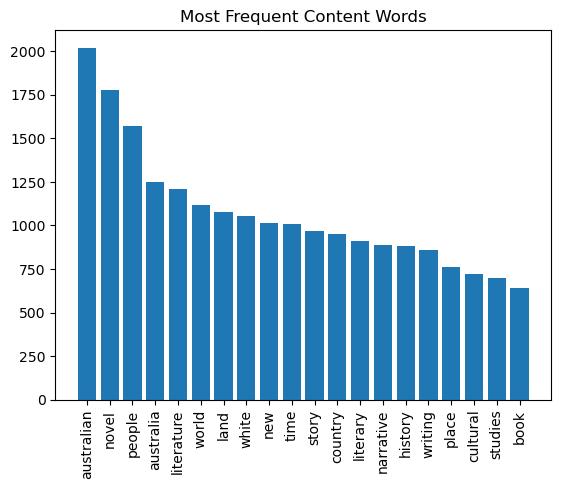

In [19]:
common = Counter(filtered_words).most_common(20)
words, counts = zip(*common)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Most Frequent Content Words")
plt.show()

# TF-IDF Analysis
TF-IDF stands for Term Frequency–Inverse Document Frequency. It is a statistical measure used in text analysis to identify words that are important within a document relative to a corpus.
It does not measure absolute importance. It measures distinctiveness.
TF-IDF is identifying terms that are:
Relatively frequent in one document
Relatively rare in the rest of the corpus
So these lists represent what distinguishes each text from the others.

The temporal distribution of key terms reveals clear patterns of lexical change across the corpus. While certain terms remain consistently present, others emerge or decline in specific periods, indicating shifts in thematic emphasis. The TF-IDF analysis highlights that distinctiveness is not static, but varies across time, with particular years characterised by unique vocabularies. The term–year matrix further demonstrates that lexical prominence fluctuates, with some terms exhibiting sharp spikes, suggesting episodic significance, while others show gradual trends, indicating sustained thematic relevance.

In [20]:
from collections import defaultdict
import re

def extract_year(filename):
    match = re.match(r"(\d{4})-\d{2}-\d{2}", filename)
    return match.group(1) if match else None

year_docs = defaultdict(list)

for filename, text in cleaned_docs.items():
    year = extract_year(filename)
    if year and isinstance(text, str):
        year_docs[year].append(text)

year_texts = {
    year: " ".join(texts)
    for year, texts in year_docs.items()
}

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000
)

years = sorted(year_texts.keys())
tfidf_matrix = vectorizer.fit_transform(year_texts[y] for y in years)
feature_names = vectorizer.get_feature_names_out()

top_terms_by_year = {}

for i, year in enumerate(years):
    row = tfidf_matrix[i].toarray()[0]
    top_indices = np.argsort(row)[-10:][::-1]  # sorted descending
    
    top_terms = [(feature_names[j], row[j]) for j in top_indices]
    
    top_terms_by_year[year] = top_terms  # <-- store it
    
    print(year)
    print([term for term, _ in top_terms])
    print()

2006
['abr', 'allrightsreserved', 'factiva', 'reviews', 'wright', 'carpentaria', 'online', 'page', 'alexis', 'archive']

2007
['people', 'wright', 'aboriginal', 'book', 'carpentaria', 'norm', 'sea', 'man', 'morf', 'eht']

2008
['eht', 'indigenous', 'wright', 'fo', 'aboriginal', 'carpentaria', 'novel', 'fi', 'people', 'norm']

2009
['eht', 'australian', 'fo', 'carpentaria', 'morf', 'australia', 'dreamhunter', 'ytisrevinu', 'enruoblem', 'wright']

2010
['indigenous', 'white', 'carpentaria', 'magic', 'wright', 'realism', 'sovereignty', 'novel', 'whiteness', 'elias']

2012
['island', 'people', 'eht', 'space', 'mp', 'fo', 'floating', 'morf', 'aboriginal', 'world']

2013
['indigenous', 'australian', 'wright', 'novel', 'carpentaria', 'people', 'aboriginal', 'australia', 'world', 'land']

2014
['wright', 'carpentaria', 'novel', 'indigenous', 'aboriginal', 'cid', 'story', 'people', 'australian', 'langton']

2015
['aboriginal', 'wright', 'people', 'indigenous', 'carpentaria', 'law', 'supra', 'wh

In [22]:
import pandas as pd

# Build term presence matrix from previous results
rows = []

for year, terms_list in top_terms_by_year.items():
    for term, score in terms_list:  # unpack (term, score)
        rows.append({
            "year": int(year),
            "term": term,
            "value": 1
        })

df = pd.DataFrame(rows)

pivot = df.pivot_table(index="year", columns="term", values="value", fill_value=0)

pivot = pivot.sort_index()  # ensure years are ordered

In [23]:
import pandas as pd

rows = []

for year, terms_list in top_terms_by_year.items():
    for term, score in terms_list:
        rows.append({
            "year": int(year),
            "term": term,
            "score": score
        })

df_terms = pd.DataFrame(rows)

score_pivot = df_terms.pivot_table(
    index="year",
    columns="term",
    values="score",
    fill_value=0
).sort_index()

score_pivot.head()

term,aboriginal,aborigines,abr,alexis,allrightsreserved,anthropocene,anthropocenes,aoe,archive,australia,...,story,supra,time,vizenor,western,white,whiteness,world,wright,ytisrevinu
year,,,,,,,,,,,,,,,,,,,,,
2006,0.000000,0.0,0.410872,0.151601,0.355319,0.0,0.0,0.0,0.132693,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.0,0.288532,0.000000
2007,0.205185,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.0,0.221384,0.000000
2008,0.179523,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.0,0.247136,0.000000
2009,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.154799,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.0,0.133404,0.139879
2010,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.34417,0.11428,0.0,0.220788,0.000000


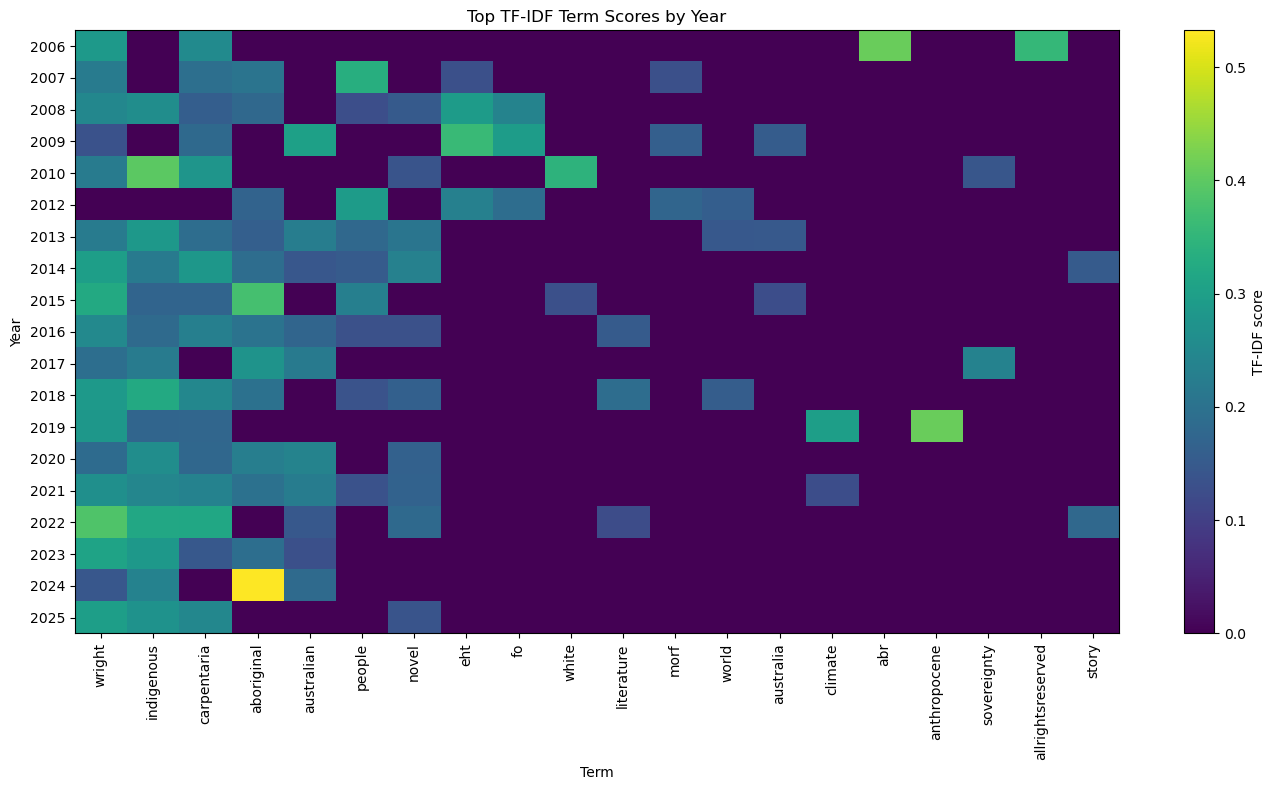

In [24]:
import matplotlib.pyplot as plt

top_terms = score_pivot.sum(axis=0).sort_values(ascending=False).head(20).index
plot_data = score_pivot[top_terms]

plt.figure(figsize=(14, 8))
plt.imshow(plot_data, aspect="auto")

plt.xticks(range(len(plot_data.columns)), plot_data.columns, rotation=90)
plt.yticks(range(len(plot_data.index)), plot_data.index)

plt.title("Top TF-IDF Term Scores by Year")
plt.xlabel("Term")
plt.ylabel("Year")
plt.colorbar(label="TF-IDF score")

plt.tight_layout()
plt.show()

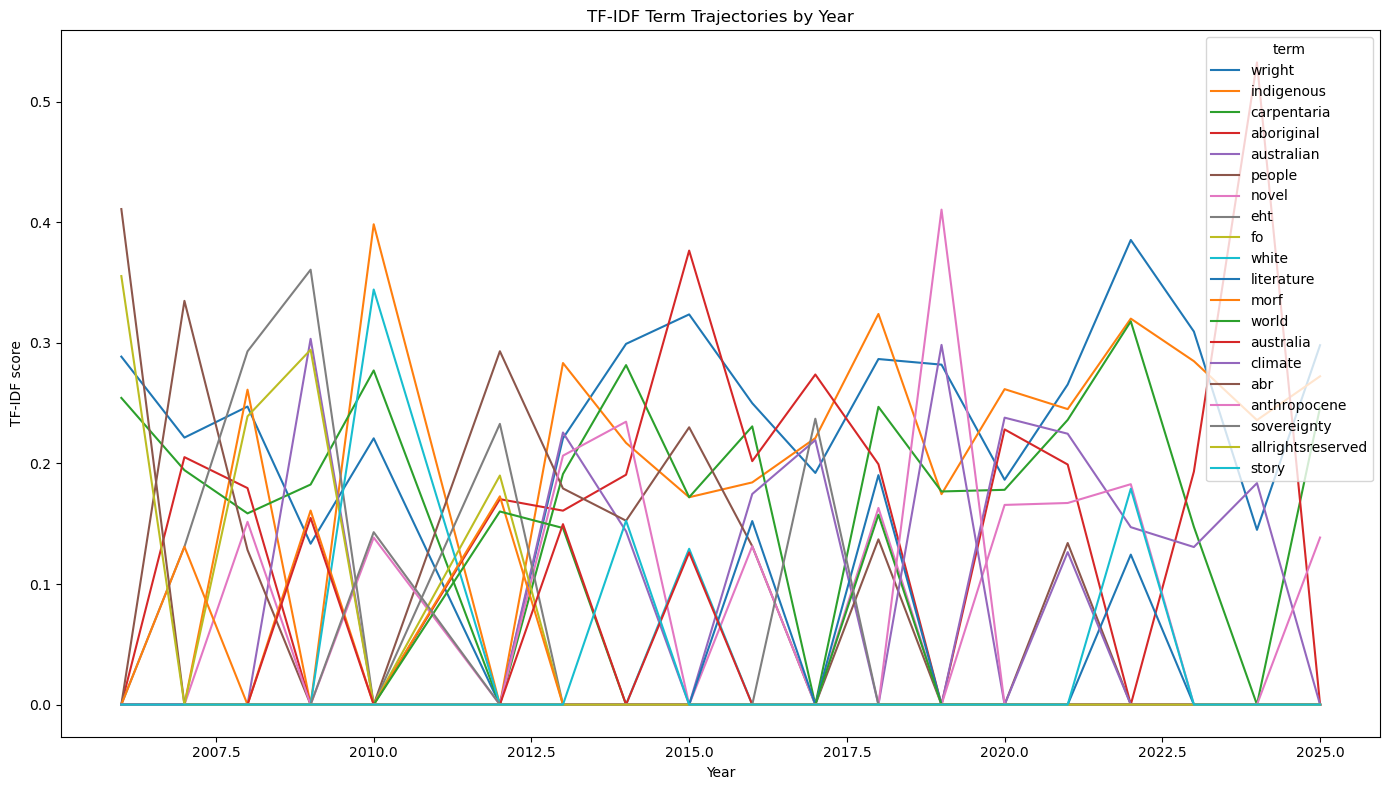

In [25]:
plot_data.plot(figsize=(14, 8))
plt.title("TF-IDF Term Trajectories by Year")
plt.xlabel("Year")
plt.ylabel("TF-IDF score")
plt.tight_layout()
plt.show()

In [26]:
noise_terms = {"eht", "fo", "morf", "fi", "mp", "cid", "dx", "aoe", "ytisrevinu", "enruoblem"}

filtered_terms = [
    term for term in score_pivot.columns
    if term not in {"wright", "carpentaria", "aboriginal", "indigenous", "novel", "australian"}
    and term not in noise_terms
]

filtered_score_pivot = score_pivot[filtered_terms]

top_filtered_terms = (
    filtered_score_pivot.sum(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .index
)

filtered_plot_data = filtered_score_pivot[top_filtered_terms]


In [27]:
#print filtered_plot_data so I can review the terms before plotting
print(filtered_plot_data)

term    people    white  literature     world  australia   climate       abr  \
year                                                                           
2006  0.000000  0.00000    0.000000  0.000000   0.000000  0.000000  0.410872   
2007  0.334775  0.00000    0.000000  0.000000   0.000000  0.000000  0.000000   
2008  0.128231  0.00000    0.000000  0.000000   0.000000  0.000000  0.000000   
2009  0.000000  0.00000    0.000000  0.000000   0.154799  0.000000  0.000000   
2010  0.000000  0.34417    0.000000  0.000000   0.000000  0.000000  0.000000   
2012  0.292993  0.00000    0.000000  0.160124   0.000000  0.000000  0.000000   
2013  0.179212  0.00000    0.000000  0.146410   0.149610  0.000000  0.000000   
2014  0.152481  0.00000    0.000000  0.000000   0.000000  0.000000  0.000000   
2015  0.229932  0.12921    0.000000  0.000000   0.126158  0.000000  0.000000   
2016  0.131369  0.00000    0.152196  0.000000   0.000000  0.000000  0.000000   
2017  0.000000  0.00000    0.000000  0.0

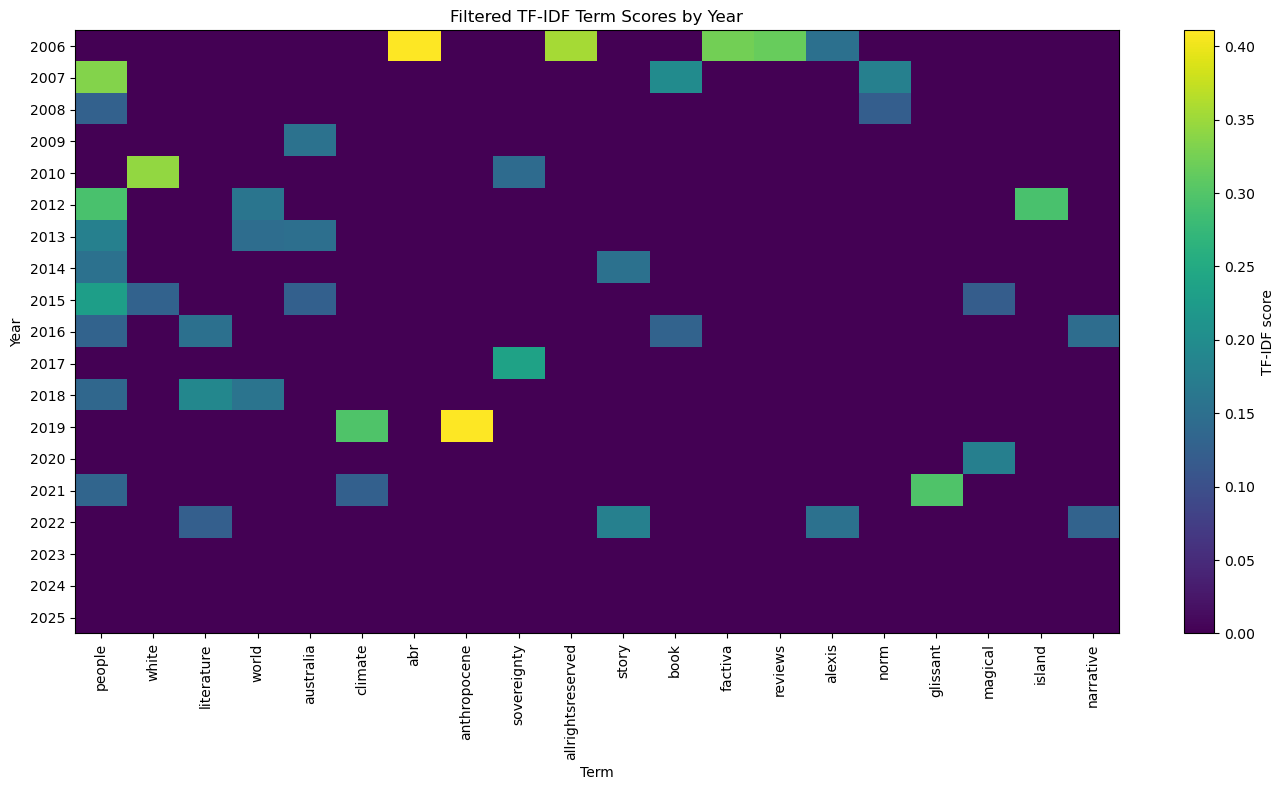

In [28]:
plt.figure(figsize=(14, 8))
plt.imshow(filtered_plot_data, aspect="auto")

plt.xticks(range(len(filtered_plot_data.columns)), filtered_plot_data.columns, rotation=90)
plt.yticks(range(len(filtered_plot_data.index)), filtered_plot_data.index)

plt.title("Filtered TF-IDF Term Scores by Year")
plt.xlabel("Term")
plt.ylabel("Year")
plt.colorbar(label="TF-IDF score")

plt.tight_layout()
plt.show()

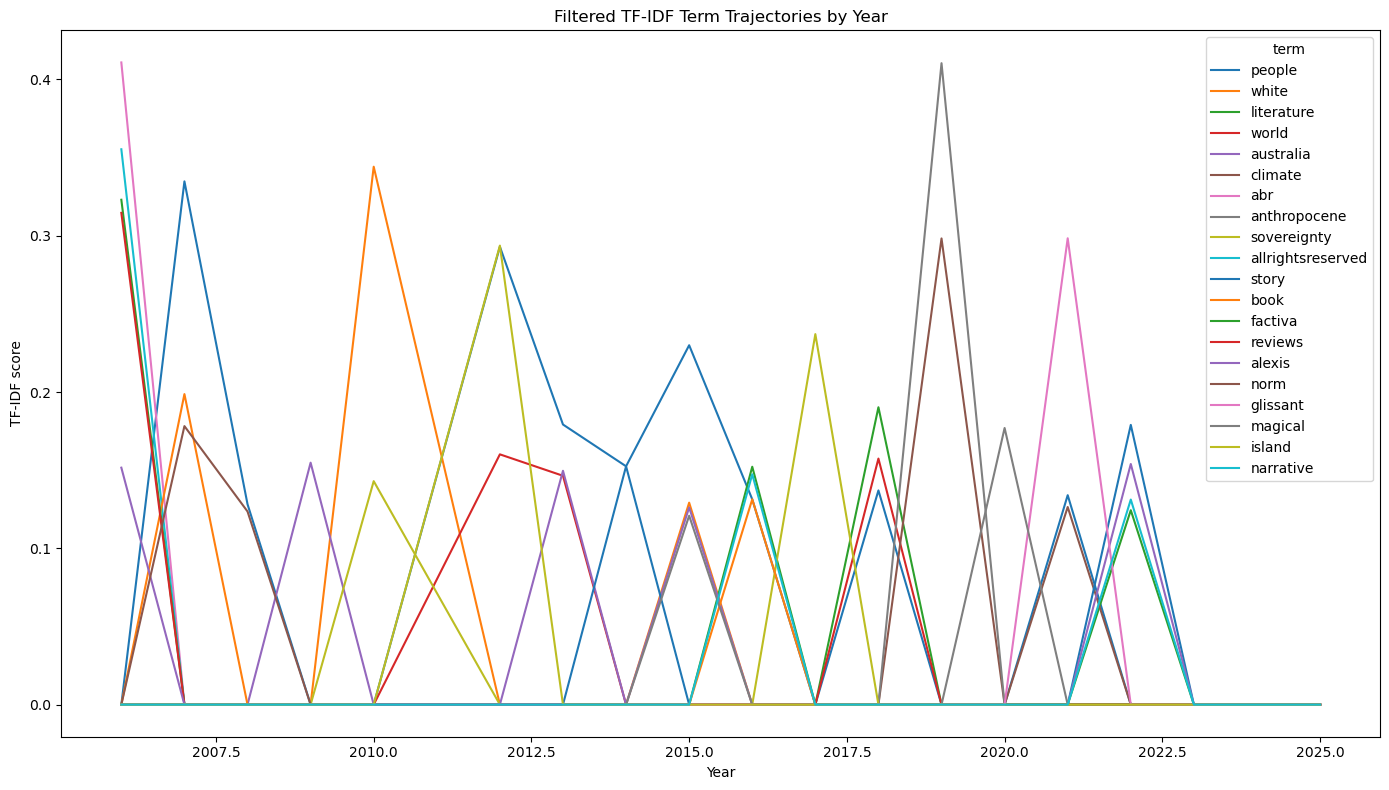

In [29]:
filtered_plot_data.plot(figsize=(14, 8))
plt.title("Filtered TF-IDF Term Trajectories by Year")
plt.xlabel("Year")
plt.ylabel("TF-IDF score")
plt.tight_layout()
plt.show()

In [30]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000
)

tfidf_matrix = vectorizer.fit_transform(cleaned_docs.values())
feature_names = vectorizer.get_feature_names_out()

Top terms in each document

In [31]:
for i, doc_name in enumerate(cleaned_docs.keys()):
    row = tfidf_matrix[i].toarray()[0]
    top_indices = np.argsort(row)[-10:]
    top_terms = [feature_names[j] for j in top_indices]
    print(doc_name)
    print(top_terms)
    print()

2013-01-01__ng-lynda__postcolonial-translocations-cultural-representation-and-critical-spatial-thinking__translocal-temporalities-in-alexis-wrights-carpentaria__book-chapter
['novel', 'australian', 'white', 'cid', 'cultures', 'culture', 'dreaming', 'indigenous', 'wright', 'translocal']

2010-01-01__brewster-anne__australian-literary-studies__indigenous-sovereignty-and-the-crisis-of-whiteness-in-alexis-wrights-carpentaria__journal-article
['people', 'norm', 'carpentaria', 'wright', 'novel', 'elias', 'white', 'whiteness', 'sovereignty', 'indigenous']

2016-01-01__mead-philip__jasal__the-unjusticeable-and-the-imaginable__journal-article
['olubas', 'brigitta', 'rights', 'people', 'anti', 'mabo', 'indigenous', 'aboriginal', 'langton', 'sovereignty']

2022-03-09__carr-richard__commonwealth-essays-and-studies__on-the-brink-of-possibility-alexis-wrights-tragicomic-novel__journal-article
['norm', 'pricklebush', 'novel', 'aboriginal', 'residents', 'brink', 'tragicomic', 'comic', 'humor', 'wright

Some meaningful stylistic signals thus far:
1. Devlin-Glass (Australian Literary Studies) ['dreamtime', 'indigenous', 'sacred', 
 'bradley', 'rainbow', 'waanyi', 'norm', 'yanyuwa']
strong evidence of:
- Indigenous cosmology focus
- Sacred geography
- Specific cultural referents

2. Ravenscroft (Cultural Studies Review) ['law', 'critics', 'realism', 'reality', 'white', 'magic']
suggests:
- Theoretical framing
- racialised reading?
- Magical realism framing

3. Shoemaker (Hecate) ['howard', 'federal', 'minister', 'prime']
suggests:
- Political-national framing
- Engagement with contemporary politics

4. Sharrad (Conference presentation) ['derrida', 'white', 'land', 'aboriginal', 'writing', 'plains', 'carpentaria', 'language', 'wright', 'promise']
suggests:
- Derrida?



In [32]:
# BUILD BIGRAM FREQUENCIES CORPUS WIDE
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import pandas as pd

# Combine all documents into one corpus list
corpus = list(cleaned_docs.values())

# Combine standard stopwords with your exclusions
combined_stopwords = set(ENGLISH_STOP_WORDS).union(exclusion_terms)

vectorizer = CountVectorizer(
    stop_words=list(combined_stopwords),
    ngram_range=(2, 2),
    token_pattern=r"(?u)\b[a-z]{3,}\b",
    min_df=2
)

X = vectorizer.fit_transform(corpus)

bigram_counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

bigram_freq = pd.DataFrame({
    "bigram": bigrams,
    "count": bigram_counts
}).sort_values(by="count", ascending=False)

bigram_freq.head(50)

,bigram,count
1762,australian literature,423
15715,magical realism,282
26554,swan book,198
17893,new york,194
4156,climate change,177
28396,university press,154
1761,australian literary,148
15696,magic realism,144
26268,study australian,143
1342,association study,140


In [33]:
"""
Map selected corpus bigrams back to individual documents.

For each specified bigram, this cell identifies the top 10 articles
(by filename) in which the bigram appears most frequently.
This enables targeted analysis of which texts most strongly
contribute to selected lexical patterns.
"""

# Build document × bigram matrix
X = vectorizer.fit_transform(corpus)
bigrams = vectorizer.get_feature_names_out()

bigram_doc_df = pd.DataFrame(
    X.toarray(),
    index=list(cleaned_docs.keys()),  # filenames here
    columns=bigrams
)

# Specify the bigrams you want to analyse
target_bigrams = [
    "climate change",
    "magical realism",
    "magic realism",
    "indigenous sovereignty",
    "world literature"
]

top_bigram_articles = {}

for bigram in target_bigrams:
    if bigram in bigram_doc_df.columns:
        article_counts = (
            bigram_doc_df[[bigram]]
            .rename(columns={bigram: "bigram_count"})
            .query("bigram_count > 0")
            .sort_values(by="bigram_count", ascending=False)
            .head(10)
            .reset_index()
            .rename(columns={"index": "filename"})
        )
        top_bigram_articles[bigram] = article_counts
    else:
        print(f"Bigram not found in vocabulary: {bigram}")

# Display
for bigram, df in top_bigram_articles.items():
    print(f"\n=== {bigram} ===")
    display(df)

Bigram not found in vocabulary: indigenous sovereignty

=== climate change ===


,filename,bigram_count
0,2021-01-01__xausa-chiara__exchanges__climate-f...,47
1,2019-02-04__crane-kylie__open-library-of-human...,45
2,2019-04-17__rowland-lucy__journal-of-postcolon...,41
3,2022-01-01__palleau-papin-unknown__commonwealt...,7
4,2015-01-01__barras-arnaud__australasian-journa...,5
5,2025-01-01__milligan-heather__critique__how-to...,4
6,2025-01-01__galanis-unknown__journal-of-the-as...,3
7,2020-01-01__takolander-maria__palgrave-handboo...,2
8,2013-01-01__barrett-susan__elohi__this-land-is...,2
9,2023-01-01__ng-unknown__the-cambridge-companio...,2



=== magical realism ===


,filename,bigram_count
0,2020-01-01__takolander-maria__palgrave-handboo...,66
1,2015-01-01__holgate-ben__journal-of-postcoloni...,56
2,2022-01-01__griffiths-michael__commonwealth-es...,55
3,2022-01-01__le-guellec-minel-unknown__etudes-a...,39
4,2010-01-01__ravenscroft-alison__cultural-studi...,19
5,2021-01-01__xausa-chiara__exchanges__climate-f...,5
6,2017-01-01__derkenne-jamie__antipodes__richard...,5
7,2015-01-01__chun-li__journal-of-literature-and...,4
8,2019-02-04__crane-kylie__open-library-of-human...,4
9,2013-09-01__polak-iva__elope-english-language-...,4



=== magic realism ===


,filename,bigram_count
0,2010-01-01__ravenscroft-alison__cultural-studi...,39
1,2017-01-01__derkenne-jamie__antipodes__richard...,17
2,2022-01-01__le-guellec-minel-unknown__etudes-a...,13
3,2021-07-01__shek-noble-liz__genre__an-indigeno...,12
4,2020-01-01__takolander-maria__palgrave-handboo...,11
5,2015-01-01__holgate-ben__journal-of-postcoloni...,11
6,2008-01-01__devlin-glass-frances__australian-l...,9
7,2013-01-01__gleeson-white-jane__jasal__capital...,8
8,2022-01-01__griffiths-michael__commonwealth-es...,5
9,2018-01-01__birns-nicholas__indigenous-transna...,3



=== world literature ===


,filename,bigram_count
0,2018-01-01__west-pavlov-and-ng__indigenous-tra...,55
1,2020-11-10__carter-david__journal-of-the-assoc...,15
2,2016-01-01__brydon-diana__ariel-a-review-of-in...,7
3,2025-01-01__galanis-unknown__journal-of-the-as...,6
4,2018-01-01__ng-unknown__indigenous-transnation...,5
5,2016-01-01__osborne-roger-whitlock-gillian__ja...,4
6,2017-12-01__rodoreda-geoff__antipodes__soverei...,3
7,2021-01-01__hamilton-unknown__journal-of-austr...,2
8,2022-01-01__le-guellec-minel-unknown__etudes-a...,2
9,2022-01-01__griffiths-michael__commonwealth-es...,2


In [34]:
"""
Map high-frequency corpus bigrams back to individual documents.

For each of the top 5 most frequent bigrams in the corpus, this cell identifies
the top 10 articles (by filename) in which the bigram appears most frequently.
This enables analysis of which texts most strongly contribute to dominant
lexical patterns.
"""

# Build document × bigram matrix
X = vectorizer.fit_transform(corpus)
bigrams = vectorizer.get_feature_names_out()

bigram_doc_df = pd.DataFrame(
    X.toarray(),
    index=list(cleaned_docs.keys()),  # filenames here
    columns=bigrams
)

# Get top 5 bigrams
top_5_bigrams = bigram_freq.head(5)["bigram"].tolist()

top_bigram_articles = {}

for bigram in top_5_bigrams:
    if bigram in bigram_doc_df.columns:
        article_counts = (
            bigram_doc_df[[bigram]]
            .rename(columns={bigram: "bigram_count"})
            .query("bigram_count > 0")
            .sort_values(by="bigram_count", ascending=False)
            .head(10)
            .reset_index()
            .rename(columns={"index": "filename"})
        )
        top_bigram_articles[bigram] = article_counts

# Display
for bigram, df in top_bigram_articles.items():
    print(f"\n=== {bigram} ===")
    display(df)


=== australian literature ===


,filename,bigram_count
0,2020-11-10__carter-david__journal-of-the-assoc...,36
1,2009-01-01__jose-nicholas__journal-of-the-asso...,31
2,2009-07-01__jose-nicholas__journal-of-the-asso...,31
3,2022-01-01__cummins-unknown__journal-of-the-as...,27
4,2022-12-01__cummins-joseph__jasal__listening-t...,27
5,2017-12-01__rodoreda-geoff__antipodes__soverei...,26
6,2016-01-01__osborne-roger-whitlock-gillian__ja...,21
7,2016-01-01__rodoreda-geoff__jasal__orality-and...,14
8,2023-05-27__brown-unknown__critique__the-inter...,13
9,2013-01-01__mcmahon-elizabeth__jasal__dorothy-...,13



=== magical realism ===


,filename,bigram_count
0,2020-01-01__takolander-maria__palgrave-handboo...,66
1,2015-01-01__holgate-ben__journal-of-postcoloni...,56
2,2022-01-01__griffiths-michael__commonwealth-es...,55
3,2022-01-01__le-guellec-minel-unknown__etudes-a...,39
4,2010-01-01__ravenscroft-alison__cultural-studi...,19
5,2021-01-01__xausa-chiara__exchanges__climate-f...,5
6,2017-01-01__derkenne-jamie__antipodes__richard...,5
7,2015-01-01__chun-li__journal-of-literature-and...,4
8,2019-02-04__crane-kylie__open-library-of-human...,4
9,2013-09-01__polak-iva__elope-english-language-...,4



=== swan book ===


,filename,bigram_count
0,2019-02-04__crane-kylie__open-library-of-human...,29
1,2015-12-01__van-rijswijk-honni__canadian-journ...,25
2,2021-01-01__xausa-chiara__exchanges__climate-f...,25
3,2015-01-01__barras-arnaud__australasian-journa...,19
4,2023-01-01__ng-unknown__the-cambridge-companio...,18
5,2016-01-01__brydon-diana__ariel-a-review-of-in...,13
6,2015-01-01__holgate-ben__journal-of-postcoloni...,12
7,2016-01-01__mead-philip__jasal__the-unjusticea...,10
8,2020-01-01__takolander-maria__palgrave-handboo...,8
9,2022-01-01__griffiths-michael__commonwealth-es...,8



=== new york ===


,filename,bigram_count
0,2020-11-10__carter-david__journal-of-the-assoc...,25
1,2016-01-01__brydon-diana__ariel-a-review-of-in...,13
2,2021-01-01__xausa-chiara__exchanges__climate-f...,11
3,2018-01-01__gunew-sneja__uncommon-wealths-in-p...,10
4,2017-01-01__derkenne-jamie__antipodes__richard...,8
5,2018-01-01__minter-and-ng-unknown__indigenous-...,7
6,2013-01-01__mcmahon-elizabeth__jasal__dorothy-...,6
7,2013-01-01__archer-lean-clare__the-internation...,6
8,2018-01-01__birns-nicholas__indigenous-transna...,5
9,2014-01-01__loomes-louise__linq-literature-in-...,5



=== climate change ===


,filename,bigram_count
0,2021-01-01__xausa-chiara__exchanges__climate-f...,47
1,2019-02-04__crane-kylie__open-library-of-human...,45
2,2019-04-17__rowland-lucy__journal-of-postcolon...,41
3,2022-01-01__palleau-papin-unknown__commonwealt...,7
4,2015-01-01__barras-arnaud__australasian-journa...,5
5,2025-01-01__milligan-heather__critique__how-to...,4
6,2025-01-01__galanis-unknown__journal-of-the-as...,3
7,2020-01-01__takolander-maria__palgrave-handboo...,2
8,2013-01-01__barrett-susan__elohi__this-land-is...,2
9,2023-01-01__ng-unknown__the-cambridge-companio...,2


=== Yearly totals ===


,year,total_words_in_year,total_docs_in_year
0,2006,5498,8
1,2007,9907,6
2,2008,22027,5
3,2009,34280,8
4,2010,20500,2
5,2012,10584,2
6,2013,74324,11
7,2014,15384,2
8,2015,49510,7
9,2016,29848,4


=== Raw bigram counts by year ===


,year,climate change_raw_count,magic realism / magical realism_raw_count,indigenous sovereignty_raw_count,world literature_raw_count
0,2006,0,0,0,0
1,2007,2,1,0,0
2,2008,0,13,0,0
3,2009,1,2,0,1
4,2010,0,55,29,0
5,2012,0,2,0,0
6,2013,4,20,8,4
7,2014,0,0,10,2
8,2015,8,75,1,0
9,2016,2,0,6,12


=== Normalised bigram frequencies per 10,000 words ===


,year,climate change_per_10k_words,magic realism / magical realism_per_10k_words,indigenous sovereignty_per_10k_words,world literature_per_10k_words
0,2006,0.000000,0.000000,0.000000,0.000000
1,2007,2.018775,1.009387,0.000000,0.000000
2,2008,0.000000,5.901848,0.000000,0.000000
3,2009,0.291715,0.583431,0.000000,0.291715
4,2010,0.000000,26.829268,14.146341,0.000000
5,2012,0.000000,1.889645,0.000000,0.000000
6,2013,0.538184,2.690921,1.076368,0.538184
7,2014,0.000000,0.000000,6.500260,1.300052
8,2015,1.615835,15.148455,0.201979,0.000000
9,2016,0.670062,0.000000,2.010185,4.020370


=== Number of documents containing each bigram ===


,year,climate change_docs_with_term,magic realism / magical realism_docs_with_term,indigenous sovereignty_docs_with_term,world literature_docs_with_term
0,2006,0,0,0,0
1,2007,2,1,0,0
2,2008,0,2,0,0
3,2009,1,2,0,1
4,2010,0,2,1,0
5,2012,0,1,0,0
6,2013,3,6,3,4
7,2014,0,0,2,2
8,2015,4,4,1,0
9,2016,2,0,3,3


=== Proportion of documents containing each bigram ===


,year,climate change_doc_proportion,magic realism / magical realism_doc_proportion,indigenous sovereignty_doc_proportion,world literature_doc_proportion
0,2006,0.000000,0.000000,0.000000,0.000000
1,2007,0.333333,0.166667,0.000000,0.000000
2,2008,0.000000,0.400000,0.000000,0.000000
3,2009,0.125000,0.250000,0.000000,0.125000
4,2010,0.000000,1.000000,0.500000,0.000000
5,2012,0.000000,0.500000,0.000000,0.000000
6,2013,0.272727,0.545455,0.272727,0.363636
7,2014,0.000000,0.000000,1.000000,1.000000
8,2015,0.571429,0.571429,0.142857,0.000000
9,2016,0.500000,0.000000,0.750000,0.750000


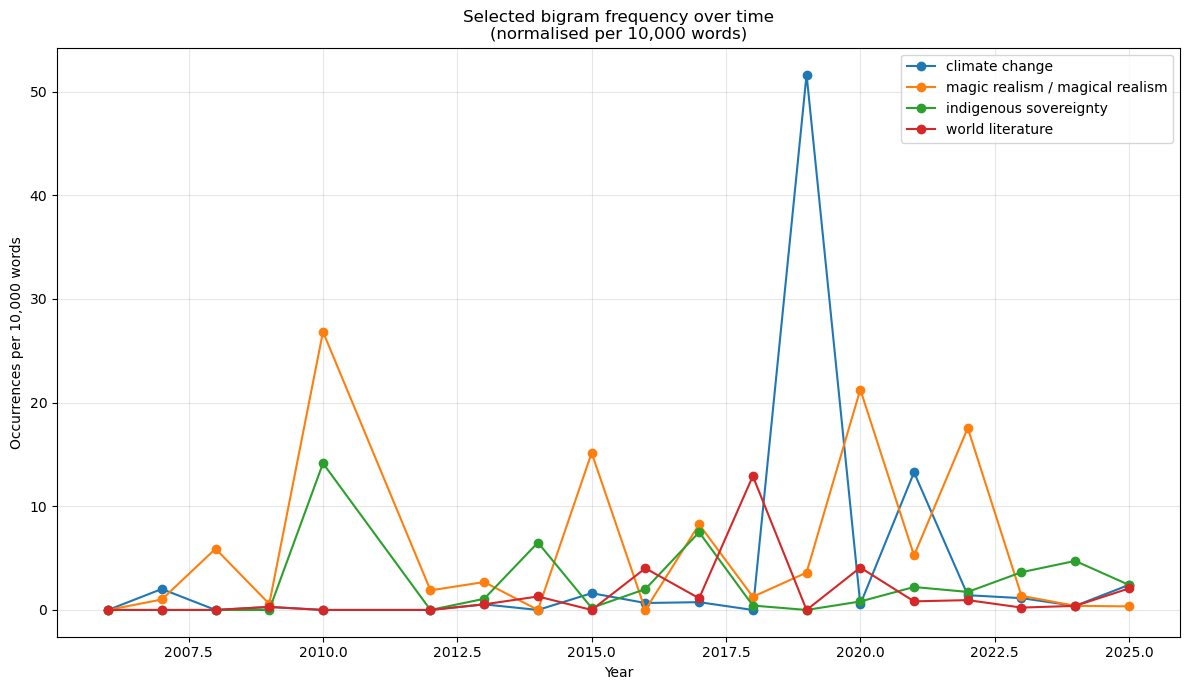

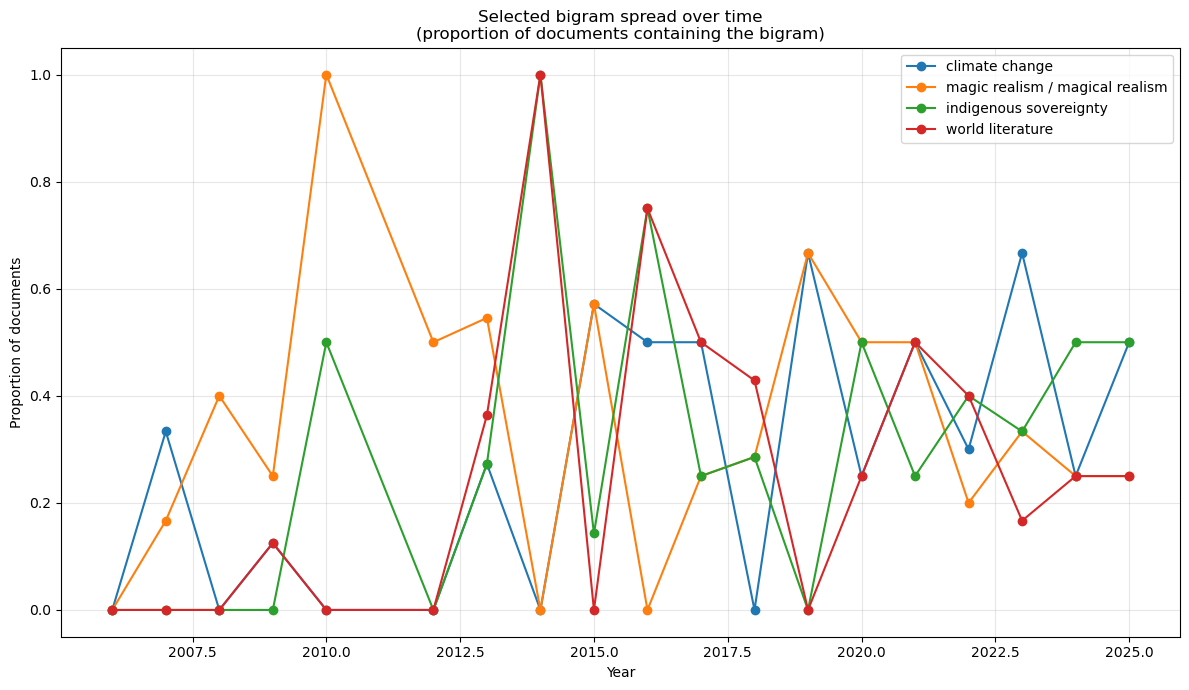

In [35]:
"""
Track selected bigrams over time with two complementary measures:

1. Frequency prominence:
   - raw yearly counts
   - normalised frequency per 10,000 words

2. Document spread:
   - number of documents per year containing the bigram
   - proportion of documents per year containing the bigram

This helps distinguish between:
- repeated use in a few documents
- broader use across many documents
"""

import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# ----------------------------
# 1. Build document × bigram matrix
# ----------------------------
vectorizer = CountVectorizer(ngram_range=(2, 2))
X = vectorizer.fit_transform(corpus)
bigrams = vectorizer.get_feature_names_out()

bigram_doc_df = pd.DataFrame(
    X.toarray(),
    index=list(cleaned_docs.keys()),
    columns=bigrams
)

# ----------------------------
# 2. Extract year from filename
# ----------------------------
def extract_year(filename):
    match = re.search(r"(19|20)\d{2}", filename)
    return int(match.group()) if match else None

bigram_doc_df["year"] = [extract_year(filename) for filename in bigram_doc_df.index]
bigram_doc_df = bigram_doc_df.dropna(subset=["year"]).copy()
bigram_doc_df["year"] = bigram_doc_df["year"].astype(int)

# ----------------------------
# 3. Add total word count per document
# ----------------------------
bigram_doc_df["total_words_in_doc"] = [len(doc.split()) for doc in corpus]

# ----------------------------
# 4. Combine 'magic realism' and 'magical realism'
# ----------------------------
bigram_doc_df["magic_realism_combined"] = 0

if "magic realism" in bigram_doc_df.columns:
    bigram_doc_df["magic_realism_combined"] += bigram_doc_df["magic realism"]

if "magical realism" in bigram_doc_df.columns:
    bigram_doc_df["magic_realism_combined"] += bigram_doc_df["magical realism"]

# ----------------------------
# 5. Define target bigrams
# ----------------------------
target_bigrams = {
    "climate change": "climate change",
    "magic realism / magical realism": "magic_realism_combined",
    "indigenous sovereignty": "indigenous sovereignty",
    "world literature": "world literature"
}

available_targets = {
    label: column_name
    for label, column_name in target_bigrams.items()
    if column_name in bigram_doc_df.columns
}

missing_targets = {
    label: column_name
    for label, column_name in target_bigrams.items()
    if column_name not in bigram_doc_df.columns
}

for label, column_name in missing_targets.items():
    print(f"Bigram not found in vocabulary: {label} ({column_name})")

# ----------------------------
# 6. Build yearly corpus totals
# ----------------------------
yearly_totals = (
    bigram_doc_df.groupby("year")
    .agg(
        total_words_in_year=("total_words_in_doc", "sum"),
        total_docs_in_year=("year", "size")
    )
    .sort_index()
)

# ----------------------------
# 7. Build yearly metrics for each target bigram
# ----------------------------
results = yearly_totals.copy()

for label, column_name in available_targets.items():
    # Raw count across all documents in that year
    yearly_raw_count = bigram_doc_df.groupby("year")[column_name].sum()

    # Number of documents in that year containing the bigram at least once
    yearly_doc_count = bigram_doc_df.assign(
        present=bigram_doc_df[column_name] > 0
    ).groupby("year")["present"].sum()

    # Add to results
    results[f"{label}_raw_count"] = yearly_raw_count
    results[f"{label}_docs_with_term"] = yearly_doc_count

    # Normalised frequency per 10,000 words
    results[f"{label}_per_10k_words"] = (
        results[f"{label}_raw_count"] / results["total_words_in_year"]
    ) * 10000

    # Proportion of documents containing the bigram
    results[f"{label}_doc_proportion"] = (
        results[f"{label}_docs_with_term"] / results["total_docs_in_year"]
    )

results = results.fillna(0)

# ----------------------------
# 8. Display summary tables
# ----------------------------
print("=== Yearly totals ===")
display(results[["total_words_in_year", "total_docs_in_year"]].reset_index())

raw_count_cols = [f"{label}_raw_count" for label in available_targets]
print("=== Raw bigram counts by year ===")
display(results[raw_count_cols].reset_index())

norm_cols = [f"{label}_per_10k_words" for label in available_targets]
print("=== Normalised bigram frequencies per 10,000 words ===")
display(results[norm_cols].reset_index())

doc_count_cols = [f"{label}_docs_with_term" for label in available_targets]
print("=== Number of documents containing each bigram ===")
display(results[doc_count_cols].reset_index())

doc_prop_cols = [f"{label}_doc_proportion" for label in available_targets]
print("=== Proportion of documents containing each bigram ===")
display(results[doc_prop_cols].reset_index())

# ----------------------------
# 9. Plot normalised frequency trends
# ----------------------------
plt.figure(figsize=(12, 7))
for label in available_targets:
    plt.plot(
        results.index,
        results[f"{label}_per_10k_words"],
        marker="o",
        label=label
    )

plt.title("Selected bigram frequency over time\n(normalised per 10,000 words)")
plt.xlabel("Year")
plt.ylabel("Occurrences per 10,000 words")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# 10. Plot document spread trends
# ----------------------------
plt.figure(figsize=(12, 7))
for label in available_targets:
    plt.plot(
        results.index,
        results[f"{label}_doc_proportion"],
        marker="o",
        label=label
    )

plt.title("Selected bigram spread over time\n(proportion of documents containing the bigram)")
plt.xlabel("Year")
plt.ylabel("Proportion of documents")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A higher score in Chart 2 the broad use of the term across all article within a given year, whereas a lower score indicates it is being used by only one paper. 

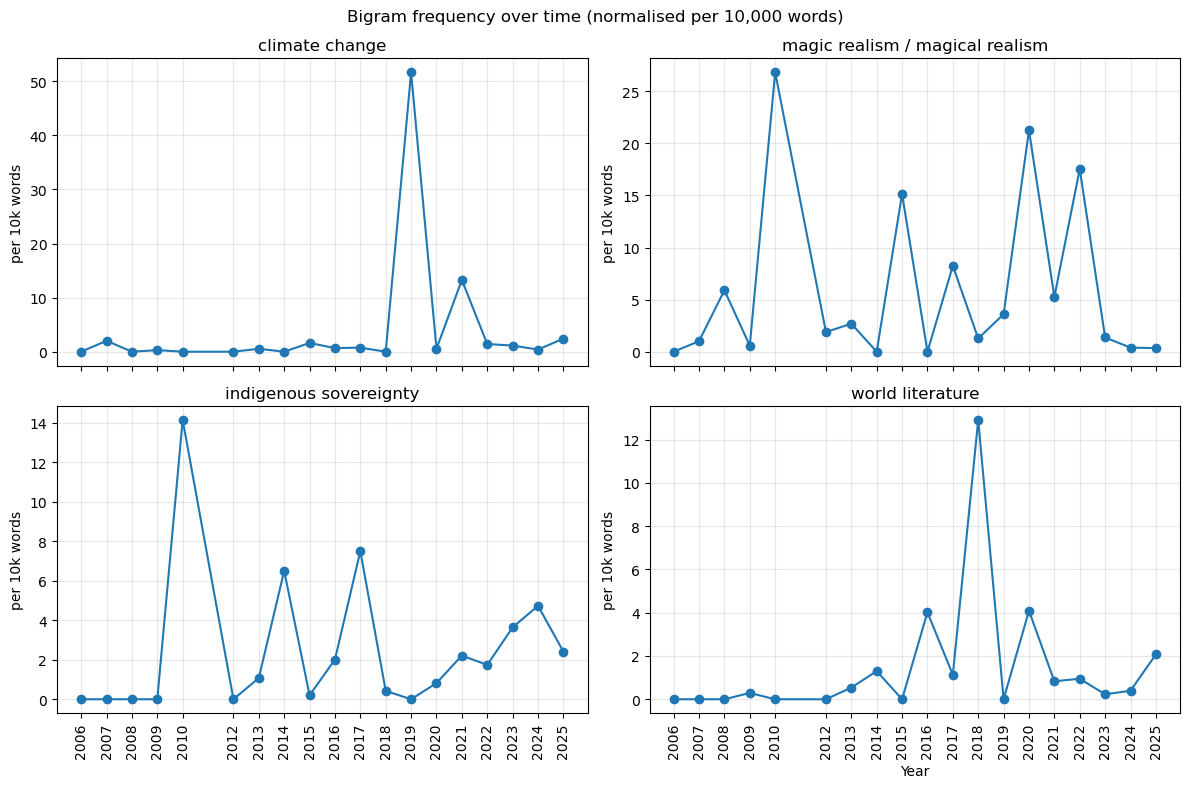

In [36]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

years = results.index.astype(int)

for i, label in enumerate(available_targets):
    ax = axes[i]
    ax.plot(
        years,
        results[f"{label}_per_10k_words"],
        marker="o"
    )
    ax.set_title(label)
    ax.set_ylabel("per 10k words")
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=90)  # rotate labels
    ax.grid(True, alpha=0.3)

plt.xlabel("Year")
plt.suptitle("Bigram frequency over time (normalised per 10,000 words)")
plt.tight_layout()
plt.show()

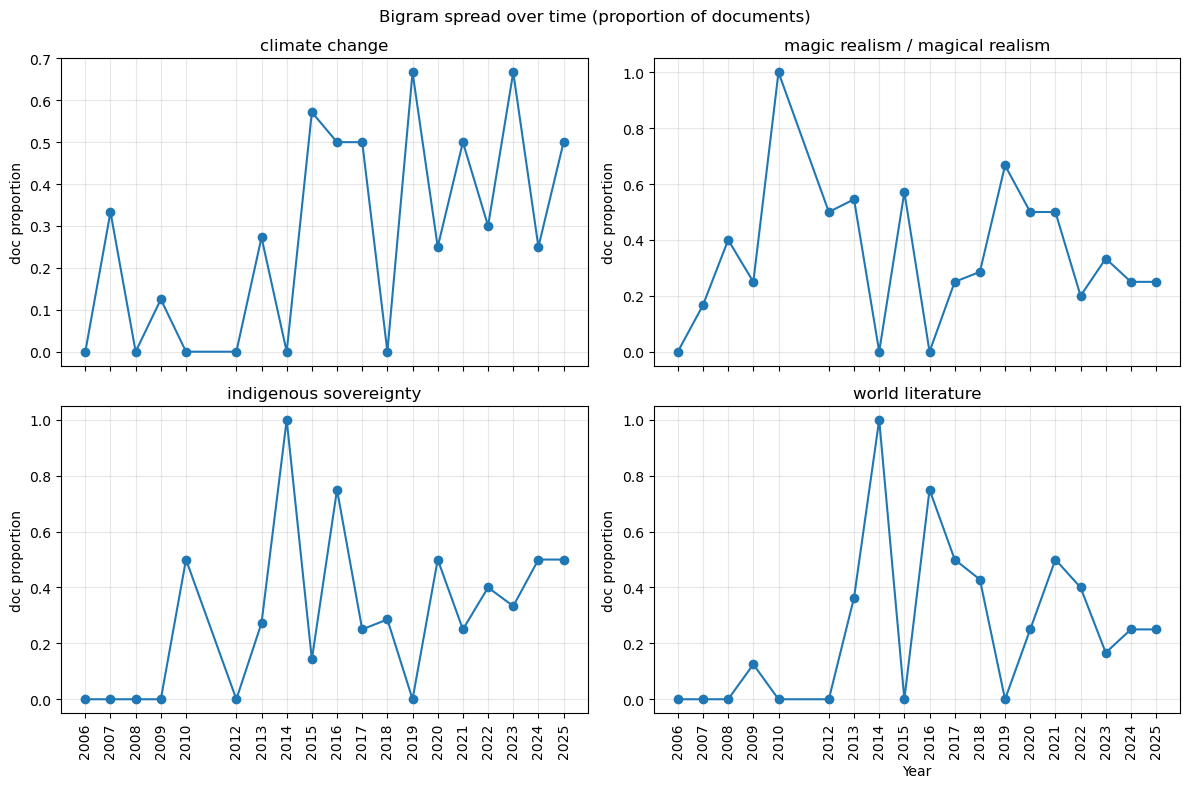

In [37]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

years = results.index.astype(int)

for i, label in enumerate(available_targets):
    ax = axes[i]
    ax.plot(
        years,
        results[f"{label}_doc_proportion"],
        marker="o"
    )
    ax.set_title(label)
    ax.set_ylabel("doc proportion")
    ax.set_xticks(years)                  # ensure integer ticks
    ax.tick_params(axis='x', rotation=90) # rotate labels
    ax.grid(True, alpha=0.3)

plt.xlabel("Year")
plt.suptitle("Bigram spread over time (proportion of documents)")
plt.tight_layout()
plt.show()

In [38]:
"""Examine collocational context"""

from collections import Counter
import re

def get_context_words(text, target_bigram, window=5):
    tokens = text.split()
    results = []
    for i in range(len(tokens) - 1):
        if tokens[i] + " " + tokens[i+1] == target_bigram:
            start = max(0, i - window)
            end = min(len(tokens), i + 2 + window)
            results.extend(tokens[start:i] + tokens[i+2:end])
    return results

context_counter = Counter()

for doc, text in cleaned_docs.items():
    context_counter.update(get_context_words(text, "climate change"))

context_counter.most_common(30)

[('the', 132),
 ('and', 94),
 ('of', 94),
 ('in', 50),
 ('to', 46),
 ('a', 31),
 ('is', 24),
 ('as', 21),
 ('for', 21),
 ('s', 21),
 ('that', 21),
 ('environmental', 18),
 ('wright', 17),
 ('with', 16),
 ('are', 15),
 ('novel', 13),
 ('temporality', 13),
 ('it', 12),
 ('by', 11),
 ('on', 11),
 ('fiction', 11),
 ('carpentaria', 10),
 ('or', 10),
 ('an', 10),
 ('about', 10),
 ('effects', 10),
 ('alexis', 9),
 ('indigenous', 9),
 ('through', 8),
 ('not', 8)]

In [39]:
#COMPARE BIGRAMS BY GENRE
from collections import defaultdict

doc_type = {name: name.split("__")[-1] for name in cleaned_docs.keys()}

for t in set(doc_type.values()):
    group_texts = [
        cleaned_docs[name]
        for name in cleaned_docs
        if doc_type[name] == t
    ]
    
    if len(group_texts) < 2:
        continue
    
    vectorizer = CountVectorizer(
        stop_words=list(combined_stopwords),
        ngram_range=(2, 2),
        token_pattern=r"(?u)\b[a-z]{3,}\b",
        min_df=1
    )
    
    X = vectorizer.fit_transform(group_texts)
    counts = X.sum(axis=0).A1
    bigrams = vectorizer.get_feature_names_out()
    
    df = pd.DataFrame({
        "bigram": bigrams,
        "count": counts
    }).sort_values(by="count", ascending=False)
    
    print(f"\n=== {t} ===")
    print(df.head(30))


=== book-review ===
                         bigram  count
19                   abr online     26
2524  factiva allrightsreserved     20
3797              kate mcfadyen     18
5124             online archive     18
4917               norm phantom     17
408             archive october     15
8621   www australianbookreview     12
1343                  com proxy     12
127               adyen reviews     12
6314               reviews tmpl     12
5134             openathens net     12
4837                  net adyen     12
7792             tmpl component     12
1430            component print     12
4461           mcfadyen reviews     12
5841           proxy openathens     12
3387                  https www     12
568    australianbookreview com     12
5758                 print kate     11
8688            ytisrevinu morf     11
2341       enruoblem ytisrevinu     11
320                   angel day     10
5079             october author     10
8072       university melbourne      9
4571

corpus already indicates that:
magical realism is a major reception frame across genres.
Scholarly criticism tends to produce collocations linking politics and cosmology (for example politics dreamtime, rainbow serpent).
There is a visible reception vocabulary around whiteness (white reader) and place (gulf country).